# Library

In [7]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
base_folder = 'DataScience'
location_base = os.path.join(os.getcwd().split(base_folder)[0], base_folder)
location_module = [os.path.join(location_base, 'Module')] 
for each in location_module:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

from import_KK import *
# DeviceStrategy_CPU()
DeviceStrategy_GPU()
from preprocessing_project_KK import *
from preprocessing_KK import *
from description_KK import *
from algorithm_machinelearning_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *
from visualization_KK import *


=========== GPU Strategy ===========
Detected GPUs:
 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TF using MirroredStrategy with 2 GPUs:
 ['/GPU:0', '/GPU:1']


======= GPU / CUDA / STATUS ========
Cuda Ready?        True
CUDA Version:      12.5.1
cuDNN Version:     9

TF Version:        2.19.0
Keras Version:     3.10.0
True
Torch Version:       2.7.1+cu126
Torch CUDA Version:  12.6
Torch cuDNN Version: 90501

Torch GPUs Available: 2
Use the GPU: NVIDIA GeForce RTX 3090



# Hyperparameters

In [3]:
# Data
FOLDER_GDM, FOLDER_GDS = get_google_drivelocation(gdrive='z', glocation=os.path.join('Research', 'SavedData', 'REES46'))
FOLDER_LOCATION = FOLDER_GDM
FILENAME = 'final_data_100k_64.parquet'
FILE_LOCATION = os.path.join(FOLDER_LOCATION, FILENAME)
LANGUAGE = 'kr'

# Data Filtering
YEAR_MIN = None
YEAR_MAX = None
AGE_MIN = None
AGE_MAX = None
GENDER = None # 'male', 'female'

# Preprocessing
Y_colname = 'is_purchased'
Year_colname = None
T_colname = None
X_reverse = None
X_handle_nonres = False
X_nonres_col = None
X_nullmax = None
X_nullmin = None
X_dummy = None
X_encoding = None
X_delYrelated = None
X_del = None
X_delete = None # X_delYrelated + X_del
# WINSORIZE_LIMITS = (0.01, 0.01)
WINSORIZE_LIMITS = None

TEST_SIZE = 0.2
YEAR_VAL, YEAR_TEST = 1, 1 # Execute when TEST_SIZE = 'Time'
RANDOM_STATE = 123
SAMPLING_METHOD = None    # 'auto' / 'RandomUnderSampler', 'TomekLinks', 'CondensedNearestNeighbour', 'OneSidedSelection' / 'SMOTE', 'SMOTETomek', 'BorderlineSMOTE', 'ADASYN'
LABEL_LIST = ['Non-purchased', 'Purchased']

# Model
# ALGO_NAMES_ML = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
ALGO_NAMES_ML = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
# ALGO_NAMES_DL = ['MLP', 'CNN', 'TabNet']
ALGO_NAMES_DL = ['TabNet']
## Common
# TUNE_TRIALS_ML = None
# TUNE_TRIALS_DL = None
TUNE_TRIALS_ML = 20
TUNE_TRIALS_DL = 5
CV_SPLITS = 5
TUNE_METRIC_ML = 'F1-score' # Default('auto'): 'F1-score', 'RMSE' - 접두사 없어도 자동으로 validation set 기준으로 판단TUNE_METRIC = 'auto'
TUNE_METRIC_DL = 'val_F1-score' # 'AUC', 'Accuracy', 'F1-score', 'loss', 'val_AUC', 'val_Accuracy', 'val_F1-score', 'val_loss'
METRIC_FINAL = "F1-score"
## DL
CLASS_WEIGHT_METHOD = 'class' # class, sample, user_defined_dict
tf.random.set_seed(123)
NODE_MLP = [128, 256, 128, 64, 32, 10]
NODE_CNN = [32, 64, 128]
VALIDATION_SPLIT = 0.2
if VALIDATION_SPLIT != None:
    VALIDATION_DATA = None
BATCH_SIZE = 64
EPOCHS = 100
VERBOSE = 0
## XAI
SHAP = True
INTERACTION = True
INTERACTION_SAMPLES = 5000
INTERACTION_BATCH = 100
X_TOP_DISPLAY = 50
## Causal Inference
if T_colname != None:
    CAUSAL_CRITERION = 'het'
    CAUSAL_HONEST = True
    CAUSAL_INFERENCE = True

# Save
SAVE_NAME_PREDSTATTR = 'DescriptiveStatistics_BinaryPredTrain.csv'
SAVE_NAME_PREDSTATTE = 'DescriptiveStatistics_BinaryPredTest.csv'
SAVE_NAME_ML = 'Performance_ML'
SAVE_NAME_DL = 'Performance_DL'
SAVE_NAME_PERFORMANCE = 'Performance.csv'
SAVE_FOLDER_BASE = os.path.join('.', 'Result', 'Base')
SAVE_FOLDER_TEST = os.path.join('.', 'Result', 'Test')

# Data Preprocessing

In [4]:
# Data Loading
df_raw = pd.read_parquet(FILE_LOCATION, engine='fastparquet')

In [5]:
# Preprocessing Data
df_prep = df_raw.copy()
X_base = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]
X_v1 = ['days_since_last_purchase', 'feat_rtb_hazard', 'feat_postbuy_refrac']
X_v2 = ['cal_is_weekend', 'cal_week_of_month', 'feat_dow_shift', 'feat_eoq_bump', 'feat_hour_shift', 'feat_payday_bump']
X_v3 = ['ctx_tc_open_rate_30d', 'feat_fatigue', 'feat_last_any_hours', 'feat_last_email_hours', 'feat_last_mobile_push_hours', 'u_cadence_std_30d', 'u_click_rate_30d', 'u_open_cnt_30d', 'u_open_rate_30d']
X_v4 = ['feat_like_last_success', 'feat_path_align', 'feat_topic_novelty', 'topic_N7', 'topic_t_since_hours']
df_prep = df_prep[[Y_colname]+X_base+X_v1+X_v2+X_v3+X_v4]

dict_rename = {
    # 1. 베이스라인 (Baseline Features)
    'avg_campaign_duration': '캠페인 지속 시간(평균)',
    'platform.': '메시지 수신: 미정의/기타',
    'channel_mobile_push': '발송 채널: 모바일 푸시',
    'channel_email': '발송 채널: 이메일',
    'camp_topicsale.out': '캠페인 주제: 할인 정보',
    'camp_topicother': '캠페인 주제: 기타',
    'platform.smartphone': '메시지 수신: 스마트폰',
    'prev_is_clicked': '메시지 클릭 여부',
    'prev_is_opened': '메시지 오픈 여부',
    'camp_channelmobile_push': '캠페인 채널: 모바일',
    'camp_channelemail': '캠페인 채널: 이메일',
    'camp_campaign_typetransactional': '캠페인 유형: 기타 거래',
    'camp_campaign_typebulk': '캠페인 유형: 전체 유저',
    'avg_time_since_last_click': '최종 클릭 경과 시간(평균)',
    'message_type_transactional': '채널 메세지 유형: 거래성 발송',
    'message_type_bulk': '채널 메세지 유형: 전체 유저 발송',
    'feat_last_mobile_push_hours': '푸시 경과 시간',
    'platform.phablet': '메시지 수신: 패블릿',
    'email_provider_mail.ru': '이메일 계정: Mail.ru',
    'total_purchases': '총 구매 횟수',
    'platform.desktop': '메시지 수신: 데스크탑',
    'avg_time_since_last_open': '최종 오픈 경과 시간(평균)',
    'email_provider_other': '이메일 계정: 기타',
    'total_messages': '총 메시지 수신 수',
    'total_campaigns': '총 캠페인 수',
    'platform.tablet': '메시지 수신: 태블릿',
    'camp_channelmultichannel': '캠페인 채널: 멀티채널',
    'message_type_trigger': '채널 메세지 유형: 특정 유저행동 발송',
    'camp_campaign_typetrigger': '캠페인 유형: 특정 유저행동',
    'avg_time_since_first_purchase': '가입 기간(첫 구매 경과)',
    'avg_time_since_complaint': '불만 접수 경과 시간(평균)',
    'email_provider_gmail.com': '이메일 계정: 지메일',
    'camp_topicleave.review': '캠페인 주제: 리뷰 요청',
    'camp_topicoffer.after.purchase': '캠페인 주제: 연관 상품 추천',
    'avg_time_since_unsubscribe': '구독 취소 경과 시간(평균)',
    'prev_is_unsubscribed': '메시지 구독 취소 여부',
    'channel_web_push': '발송 채널: 웹 푸시',
    'camp_topicevent': '캠페인 주제: 이벤트',
    'camp_topichappy.birthday': '캠페인 주제: 생일 축하',
    'camp_channelsms': '캠페인 채널: SMS',
    # 2. 마케팅 채널 효과성 패턴
    'topic_N7': '주제 노출 수(7일)',
    'feat_like_last_success': '성공 캠페인 유사도',
    'topic_t_since_hours': '주제 경과 시간',
    'feat_topic_novelty': '주제 신선도',
    'feat_path_align': '성공 경로 일치도',
    # 3. 구매/재구매 주기 패턴
    'days_since_last_purchase': '마지막 구매 경과일',
    'feat_postbuy_refrac': '구매 후 불응기',
    'feat_rtb_hazard': '재구매 준비도',
    # 4. 시계열적 반응 패턴
    'cal_is_weekend': '주말 여부',
    'feat_dow_shift': '선호 요일 일치도',
    'feat_payday_bump': '급여일 근접도',
    'cal_week_of_month': '주차 정보',
    'feat_eoq_bump': '분기 말 근접도',
    'feat_hour_shift': '선호 시간대 일치도',
    # 5. 마케팅 피로도 패턴
    'u_open_rate_30d': '유저 오픈율(30일 내)',
    'u_click_rate_30d': '유저 클릭율(30일 내)',
    'u_open_cnt_30d': '유저 오픈 횟수(30일 내)',
    'feat_fatigue': '마케팅 피로도',
    'feat_last_email_hours': '이메일 경과 시간',
    'u_cadence_std_30d': '발송 간격 표준편차',
    'ctx_tc_open_rate_30d': '채널별 특정 주제 캠페인 오픈율(30일 내)',
    'feat_last_any_hours': '마지막 접촉 경과 시간'
}
df_prep.rename(columns=dict_rename, inplace=True)

# Preprocessing for Modeling
X_train, X_test, Y_train, Y_test, \
TASK, df_final, X_colname, \
CV_SPLITS, LABEL_LIST = preprocessing_modeling_KK(
    df_raw=df_prep, Y_colname=Y_colname, Year_colname=Year_colname, 
    X_delete=X_delete, X_dummy=X_dummy, 
    winsorize_limits=WINSORIZE_LIMITS,
    test_size=TEST_SIZE, year_val=YEAR_VAL, year_test=YEAR_TEST,
    sampling_method=SAMPLING_METHOD,
    label_list=LABEL_LIST,
)


▶ Detected Task Type: [ CLASSIFICATION ] (Target: binary)

Starting Preprocessing for CLASSIFICATION...
Initial Shape: (9999329, 65)

Imputing Missing Values separately...

[Train Mode] Analyzing missing patterns... (Task: CLASSIFICATION)
 - Columns marked for deletion: 2 cols
Filling Null Values...
Complete! All missing values are cleanly imputed.

[Test/Inference Mode] Applying Train imputation states (Anti-Leakage)...
Filling Null Values...
Complete! All missing values are cleanly imputed.
[Baseline Characteristics Summary] (2-Class Comparison)
▶ Total X: 62 | Analysis X: 62
▶ Significant X (p <= 0.05): 57 (91.9%)
Saving Complete: /mnt/c/DataScience/[DIVE]/Project/CRMRetention/Result/DescriptiveStatistics_Classification.csv



Non-purchased        Purchased  \
Feature        Category / Metric                                         
캠페인 지속 시간(평균)  Mean ± SD                 5.44 ± 50.45     20.48 ± 7.92   
메시지 수신: 미정의/기타 0                      308,826 (3.87%)   1,700 (17.22%)   
               1                   7,680,765 (96.13%)   8,172 (82.78%)   
발송 채널: 모바일 푸시  0                   5,118,139 (64.06%)   9,550 (96.74%)   
               1                   2,871,452 (35.94%)      322 (3.26%)   
...                                               ...              ...   
캠페인 주제: 이벤트    1                        2,393 (0.03%)        0 (0.00%)   
캠페인 주제: 생일 축하  0                   7,980,726 (99.89%)   9,863 (99.91%)   
               1                        8,865 (0.11%)        9 (0.09%)   
캠페인 채널: SMS    0                  7,989,516 (100.00%)  9,872 (100.00%)   
               1                           75 (0.00%)        0 (0.00%)   

                                                   Statistics  
Feature        Category / Metric                               
캠페인 지속 시간(평균)  Mean ± SD               $T$=-184.08, $p$<0.001  
메시지 수신: 미정의/기타 0                  $\chi^2$=4709.65, $p$<0.001  
               1                                               
발송 채널: 모바일 푸시  0                  $\chi^2$=4574.03, $p$<0.001  
               1                                               
...                                                       ...  
캠페인 주제: 이벤트    1                                               
캠페인 주제: 생일 축하  0                      $\chi^2$=0.19, $p$=0.66  
               1                                               
캠페인 채널: SMS    0                      $\chi^2$=0.00, $p$=1.00  
               1                                               

[120 rows x 3 columns]

(7999463, 62) (7999463, 1)
(1999866, 62) (1999866, 1)
Execution Time: 0:02:14


# Modeling

## Machine Learning

In [ ]:
# ML Modeling
results_ML, scores_ML = modeling_ML(
    algos=ALGO_NAMES_ML,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    task=TASK,
    X_colname=X_colname,
    params=None, # 특정 알고리즘
    tune_trials=TUNE_TRIALS_ML, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC_ML,
    X_top_display=X_TOP_DISPLAY, 
    label_list=LABEL_LIST,
    random_state=RANDOM_STATE,
)


▶ Inherited Task Type: [ CLASSIFICATION ]
    ▷ Inherited label_list: ['Non-purchased', 'Purchased']

   Running Machine Learning Algorithm: Random Forest (classification)
Learning...:  2026-07-30 17:12:51.087975


  0%|          | 0/20 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'use_max_depth': True, 'n_estimators': 200, 'max_depth': 7, 'max_features': 'log2', 'min_samples_split': 6, 'min_samples_leaf': 24, 'bootstrap': True, 'scaler_type': 'StandardScaler'}
  ▶ [Trial 1] Params: {'use_max_depth': True, 'n_estimators': 100, 'max_depth': 9, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 33, 'bootstrap': True, 'scaler_type': 'RobustScaler'}
  ▶ [Trial 2] Params: {'use_max_depth': True, 'n_estimators': 200, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 40, 'bootstrap': False, 'scaler_type': 'None'}
  ▶ [Trial 3] Params: {'use_max_depth': False, 'n_estimators': 500, 'max_features': 'sqrt', 'min_samples_split': 5, 'min_samples_leaf': 46, 'bootstrap': True, 'scaler_type': 'StandardScaler'}
  ▶ [Trial 4] Params: {'use_max_depth': True, 'n_estimators': 300, 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 6, 'min_samples_leaf': 17, 'bootstrap': True, 'scaler_type': 'MinMax

## Deep Learning

In [8]:
# DL Modeling
results_DL, scores_DL = modeling_DL(
    algos=ALGO_NAMES_DL,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    task=TASK,
    class_weight_method=CLASS_WEIGHT_METHOD,
    node_list=None, # 특정 알고리즘
    validation_split=VALIDATION_SPLIT,
    validation_data=VALIDATION_DATA,
    tune_trials=TUNE_TRIALS_DL, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC_DL,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    earlystop_patient=None,
    shap_display=False,
    label_list=LABEL_LIST,
    random_state=RANDOM_STATE,
)


▶ Manually Specified Task Type: [ classification ]
   ▷ Auto-computed Fixed Class Weights for DL: {0: 0.5006178038400213, 1: 405.1591876012966}

   Running Deep Learning Algorithm: TabNet (classification)
[Info] Starting Hyperparameter Optimization (Trials: 5)...


  0%|          | 0/5 [00:00<?, ?it/s]

  ▶ [Trial 0] Params: {'scaler_type': 'None', 'n_layers': 3, 'l2_regularization': 3.586010394481008e-05, 'batch_normalization': False, 'hidden_activation': 'swish', 'dropout': 0.021810159551993502, 'batch_size': 32, 'optimizer': 'adam', 'learning_rate': 0.00024017312241478213, 'batch_size_tabnet': 128, 'n_d': 16, 'n_steps': 3, 'gamma': 1.430713998781134, 'n_independent': 2, 'n_shared': 2, 'mask_type': 'sparsemax'}
[W 2026-08-06 11:16:04,068] Trial 0 failed with parameters: {'scaler_type': 'None', 'n_layers': 3, 'l2_regularization': 3.586010394481008e-05, 'batch_normalization': False, 'hidden_activation': 'swish', 'dropout': 0.021810159551993502, 'batch_size': 32, 'optimizer': 'adam', 'learning_rate': 0.00024017312241478213, 'batch_size_tabnet': 128, 'n_d': 16, 'n_steps': 3, 'gamma': 1.430713998781134, 'n_independent': 2, 'n_shared': 2, 'mask_type': 'sparsemax'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/kk/.conda/envs/kk_gpu/li

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x769d0d191790>>
Traceback (most recent call last):
  File "/home/kk/.conda/envs/kk_gpu/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 

KeyboardInterrupt



# Performance Summary

In [8]:
# Result Summary
folder_location = os.path.join(os.getcwd(),'Result')
scores = prediction_summary(
    folder_location=folder_location, 
    algonames=ALGO_NAMES_ML + ALGO_NAMES_DL,
    save_name=SAVE_NAME_PERFORMANCE,
)

### Performance Summary : 3 Algorithms ###

>>> [Train set] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,2400002,1687,2397040,0,1275,1.0000,0.5695,1.0000,0.7257,0.9995,0.7848,1.0000
1,LightGBM,2400002,1987,2397040,0,975,1.0000,0.6708,1.0000,0.8030,0.9996,0.8354,1.0000
2,CatBoost,2400002,1602,2396966,74,1360,0.9558,0.5409,1.0000,0.6908,0.9994,0.7704,0.9992



>>> [Validation(CV)] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,2400002,1450,2397016,24,1512,0.4715,0.5760,0.9992,0.5183,0.9987,0.7876,0.9916
1,LightGBM,2400002,1486,2397021,19,1476,0.3423,0.6266,0.9985,0.4426,0.9981,0.8126,0.9948
2,CatBoost,2400002,1526,2396966,74,1436,0.1271,0.9632,0.9918,0.2245,0.9918,0.9775,0.9975



>>> [Test set] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,600001,349,599257,4,391,0.9887,0.4716,1.0000,0.6386,0.9993,0.7358,0.9842
1,LightGBM,600001,374,599221,40,366,0.9034,0.5054,0.9999,0.6482,0.9993,0.7527,0.9856
2,CatBoost,600001,412,599074,187,328,0.6878,0.5568,0.9997,0.6154,0.9991,0.7782,0.9966



>>> [Entire population] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,3000003,2036,2996297,4,1666,0.9980,0.5500,1.0000,0.7092,0.9994,0.7750,0.9984
1,LightGBM,3000003,2361,2996261,40,1341,0.9833,0.6378,1.0000,0.7737,0.9995,0.8189,0.9968
2,CatBoost,3000003,2014,2996040,261,1688,0.8853,0.5440,0.9999,0.6739,0.9994,0.7720,0.9986


# Best Model Prediction

▶ Searching Directory: /mnt/c/DataScience/Publication/202402_IPVPrediction/Model
Loading Model: XGBoost
   - File: best_model_XGBoost_20260715_214855.pkl
   - Successfully Loaded.
[XGBoost] 모델 내부 변수명이 성공적으로 수정되었습니다.
Performance: 


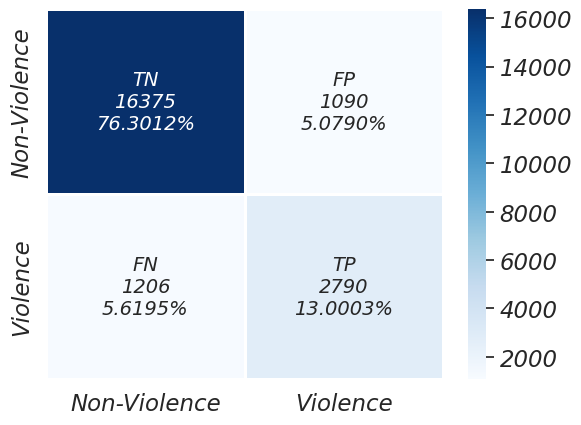

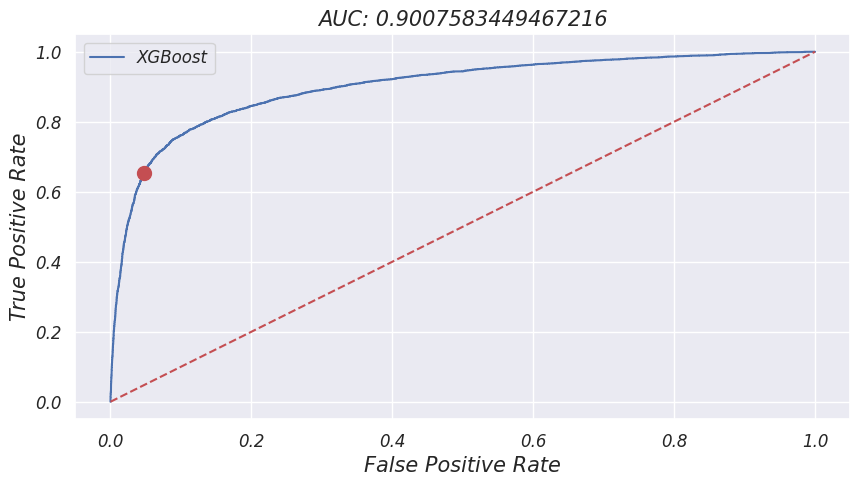

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,Train set,85840,15982,69799,59,0,0.9963,1.0000,0.9992,0.9982,0.9993,0.9996,1.0000
1,XGBoost,Test set,21461,2790,16375,1090,1206,0.7191,0.6982,0.9376,0.7085,0.8930,0.8179,0.9008
2,XGBoost,Entire population,107301,18772,86174,1149,1206,0.9423,0.9396,0.9868,0.9410,0.9781,0.9632,0.9886


Saved: ./Result/Screening_Report_XGBClassifier.csv

   [XGBClassifier] Feature Screening Report (Normalized to 100%)
>>> [Cumulative Importance >= 99.0%] (Delete Count: 3)
삭제변수명: ['Work start month', 'Industry (sector)', 'Sex']
------------------------------------------------------------
>>> [Cumulative Importance >= 95.0%] (Delete Count: 9)
삭제변수명: ['Number of private health insurance policies', 'Current income (regular/ordinary income)', 'Satisfaction with household income', 'Primary diagnosis', 'Number of outpatient visits in the past year', 'Occupation', 'Work start month', 'Industry (sector)', 'Sex']
------------------------------------------------------------
>>> [Cumulative Importance >= 90.0%] (Delete Count: 16)
삭제변수명: ['Other interest payments', 'Taxes—income tax', 'Work duration (days)', 'Satisfaction with job', 'Felt quite depressed', 'Satisfaction with health', 'Other consumption expenditure', 'Number of private health insurance policies', 'Current income (regular/ordinary i

,Feature,Feature Importance (Gini/Gain),Importance (%),Cumulative Importance (%)
0,Frequent disagreements among family members,0.0309,3.0891,3.0891
1,Family members often blame each other,0.0256,2.5623,5.6513
2,Satisfaction with family life,0.0255,2.5471,8.1984
3,Top issue causing worry or conflict in the past year (1st),0.0193,1.9256,10.1240
4,Satisfaction with relationship with spouse/partner,0.0166,1.6624,11.7863
...,...,...,...,...
103,Number of outpatient visits in the past year,0.0062,0.6190,97.8739
104,Occupation,0.0059,0.5875,98.4614
105,Work start month,0.0058,0.5823,99.0437
106,Industry (sector),0.0055,0.5531,99.5967


In [6]:
# Model Loaded
if METRIC_FINAL in ['RMSE']:
    best_scoreidx = np.argmin(scores[scores.Dataset=='Test set'][METRIC_FINAL])
else:
    best_scoreidx = np.argmax(scores[scores.Dataset=='Test set'][METRIC_FINAL])
BEST_ALGO = scores[scores.Dataset=='Test set'].iloc[best_scoreidx]['Algorithm']
BEST_MODEL, BEST_PARAMS = Loading_ModelBestParams(algo_name=BEST_ALGO)
OPTIMAL_THRESHOLD = BEST_PARAMS.get('optimal_threshold', 0.5)
if BEST_ALGO in ['MLP', 'CNN']:
    KERAS = True
else:
    KERAS = False
    BEST_MODEL = modeling_featurename(BEST_MODEL, BEST_ALGO, X_colname)    

# Performance Evaluation
if METRIC_FINAL in ['RMSE']:
    Scores_Test = prediction_reg(BEST_MODEL, X_train, Y_train, X_test, Y_test,
                                 ALGO_NAME=BEST_ALGO, keras=KERAS)
else:
    Scores_Test = prediction_class(BEST_MODEL, X_train, Y_train, X_test, Y_test,
                                   threshold=OPTIMAL_THRESHOLD,
                                   LABEL_LIST=LABEL_LIST, ALGO_NAME=BEST_ALGO, keras=KERAS)
display(Scores_Test)

# Feature Importance
df_importance = modeling_featureimportance(BEST_MODEL, [0.5, 0.75, 0.9, 0.95, 0.99])
display(df_importance)

# Explanation

[Auto-Config] Detected Algorithm: XGBoost | Type: Tree | Link: logit
[SHAP] Pipeline 객체가 감지되어 내부 스케일러로 데이터를 자동 변환합니다.
Loading existing SHAP values: ./Model/shap_values_XGBoost_20260716_091745.pkl
[Success] Loaded SHAP value feature names have been updated in-memory!
Loading existing SHAP interaction values: ./Model/shap_intervalues_XGBoost_20260716_113342.pkl

[Train Dataset Contribution Calculation]: 2026-07-21 16:55:28.102486
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████████████████████████████████████████████████| 108/108 [00:01<00:00, 59.44it/s]


,Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)",Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)"
0,Satisfaction with relationship with spouse/partner,0.7717,7.7907,1.4897,0.1303,0.1673,0.7631,0.9628,NaN,Satisfaction with family life,0.5176,5.2255,1.0244,-0.0150,-0.0353,-0.8900,-0.9713,NaN
1,Frequent disagreements among family members,0.6828,6.8936,1.3567,0.2135,0.2845,0.8666,0.9664,NaN,Family members discuss problems calmly,0.3365,3.3969,0.6792,-0.0035,-0.0191,-0.9009,-0.9505,NaN
2,Family members often blame each other,0.3623,3.6576,0.7239,0.1882,0.2471,0.8331,0.9353,NaN,Age,0.3271,3.3028,0.6526,0.0248,0.0181,-0.8497,-0.9751,NaN
3,Family members throw objects in anger,0.2831,2.8578,0.5820,0.1642,0.2103,0.8856,0.9655,NaN,Self-rated health status,0.2351,2.3739,0.4628,0.0403,0.0420,-0.7525,-0.9484,NaN
4,Top issue causing worry or conflict in the past year (1st),0.2047,2.0666,0.2665,0.0789,0.1073,0.2072,0.5688,NaN,Support from non-household children (cash or in-kind),0.1676,1.6917,0.3133,-0.0234,-0.0459,-0.6151,-0.8336,NaN



[Test Dataset Contribution Calculation]: 2026-07-21 16:55:30.186012
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 234.08it/s]


,Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)",Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)"
0,Satisfaction with relationship with spouse/partner,0.7676,7.8801,1.4809,0.1113,0.2232,0.7673,0.9660,NaN,Satisfaction with family life,0.5145,5.2815,1.0174,-0.0315,-0.0365,-0.8921,-0.9752,NaN
1,Frequent disagreements among family members,0.6804,6.9848,1.3517,0.1879,0.3611,0.8741,0.9726,NaN,Family members discuss problems calmly,0.3331,3.4198,0.6721,-0.0226,-0.0132,-0.9054,-0.9548,NaN
2,Family members often blame each other,0.3594,3.6894,0.7172,0.1676,0.3141,0.8375,0.9385,NaN,Age,0.3262,3.3490,0.6499,0.0092,0.0348,-0.8529,-0.9782,NaN
3,Family members throw objects in anger,0.2820,2.8946,0.5812,0.1424,0.2696,0.8915,0.9682,NaN,Self-rated health status,0.2357,2.4200,0.4625,0.0205,0.0654,-0.7623,-0.9560,NaN
4,Top issue causing worry or conflict in the past year (1st),0.2015,2.0685,0.2554,0.0639,0.1412,0.2143,0.5907,NaN,Support from non-household children (cash or in-kind),0.1688,1.7325,0.3154,-0.0334,-0.0635,-0.6120,-0.8390,NaN



[Train Dataset Beeswarm Visualization]: 2026-07-21 16:55:30.836931
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


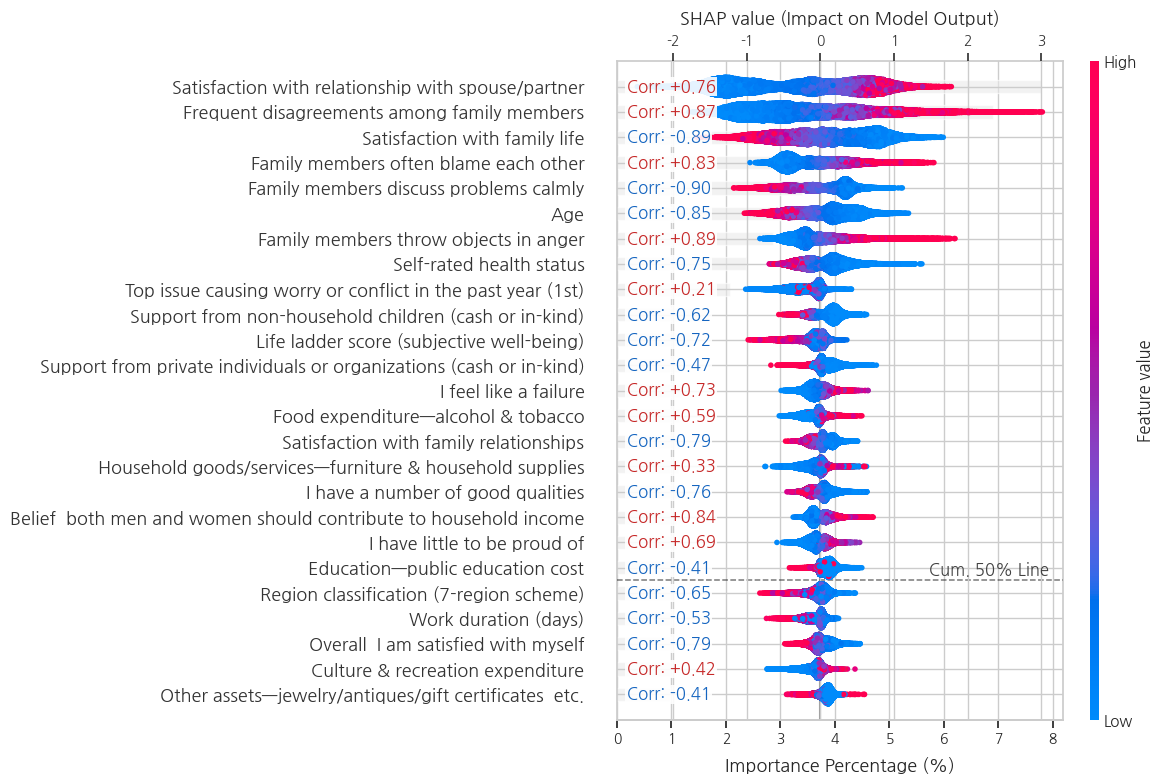


[Test Dataset Beeswarm Visualization]: 2026-07-21 16:55:45.661101
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


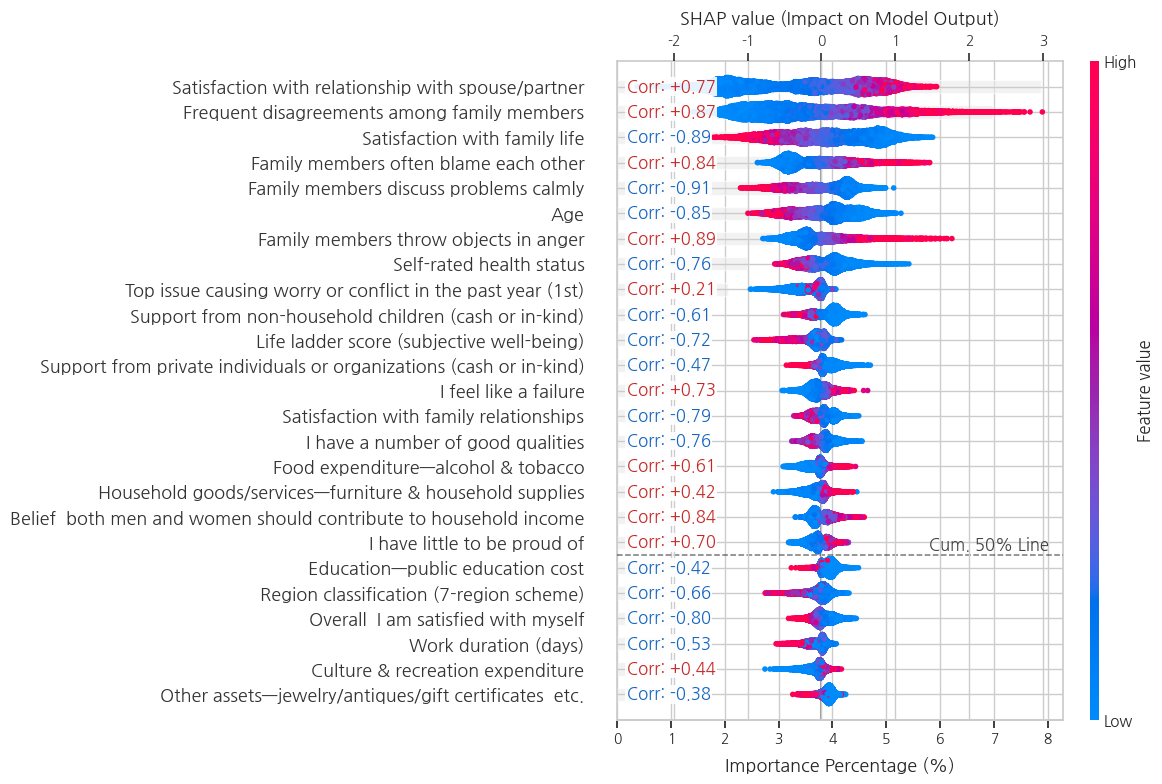


[Test Dataset Interaction]: 2026-07-21 16:55:49.796502
Feature Interactive Contribution...


Calculating Correlations: 100%|██████████████████████████████████████████████████████| 108/108 [00:00<00:00, 225.78it/s]


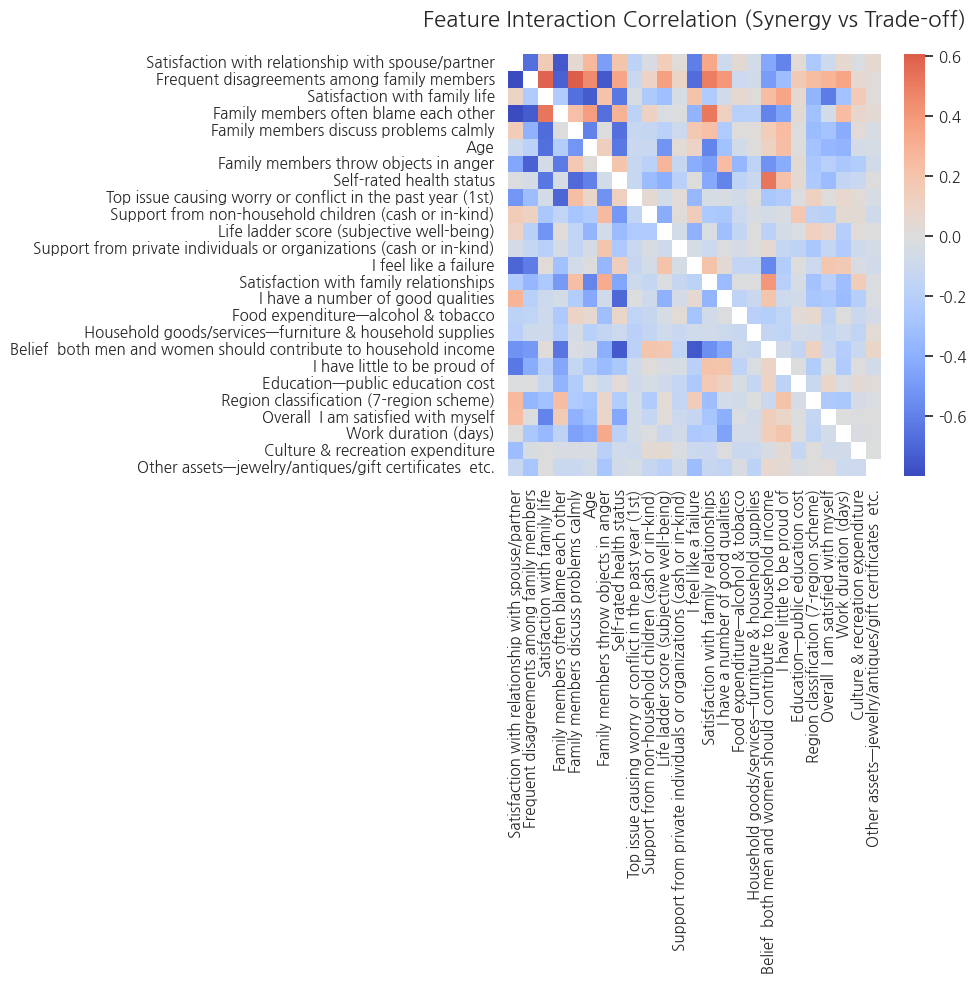


💡 Top 25 Feature Interaction Pairs (Impact Size & Direction)


,Feature 1,Feature 2,Impact Size (Magnitude),Interaction Share (%),Cumulative Share (%),Interaction Correlation,Relationship
0,Frequent disagreements among family members,Satisfaction with family life,0.1757,0.5700,0.5700,0.5879,Synergy (+)
1,Satisfaction with relationship with spouse/partner,Frequent disagreements among family members,0.0980,0.3200,0.8900,-0.6701,Trade-off (-)
2,Satisfaction with family life,Family members often blame each other,0.0812,0.2600,1.1500,-0.2367,Trade-off (-)
3,Frequent disagreements among family members,Age,0.0688,0.2200,1.3700,0.4492,Synergy (+)
4,Satisfaction with relationship with spouse/partner,Family members often blame each other,0.0648,0.2100,1.5800,-0.7505,Trade-off (-)
5,Family members often blame each other,Family members throw objects in anger,0.0619,0.2000,1.7800,-0.6707,Trade-off (-)
6,Satisfaction with relationship with spouse/partner,Satisfaction with family life,0.0588,0.1900,1.9800,0.1594,Synergy (+)
7,Satisfaction with relationship with spouse/partner,Age,0.0560,0.1800,2.1600,0.2630,Synergy (+)
8,Frequent disagreements among family members,Family members discuss problems calmly,0.0538,0.1700,2.3300,0.6072,Synergy (+)
9,Frequent disagreements among family members,Self-rated health status,0.0527,0.1700,2.5000,0.3542,Synergy (+)



[Test Dataset Sensitivity Analysis]: 2026-07-21 16:55:51.950659
Sensitivity Analysis (ICE & PDP Plot) for Top 25 Features...


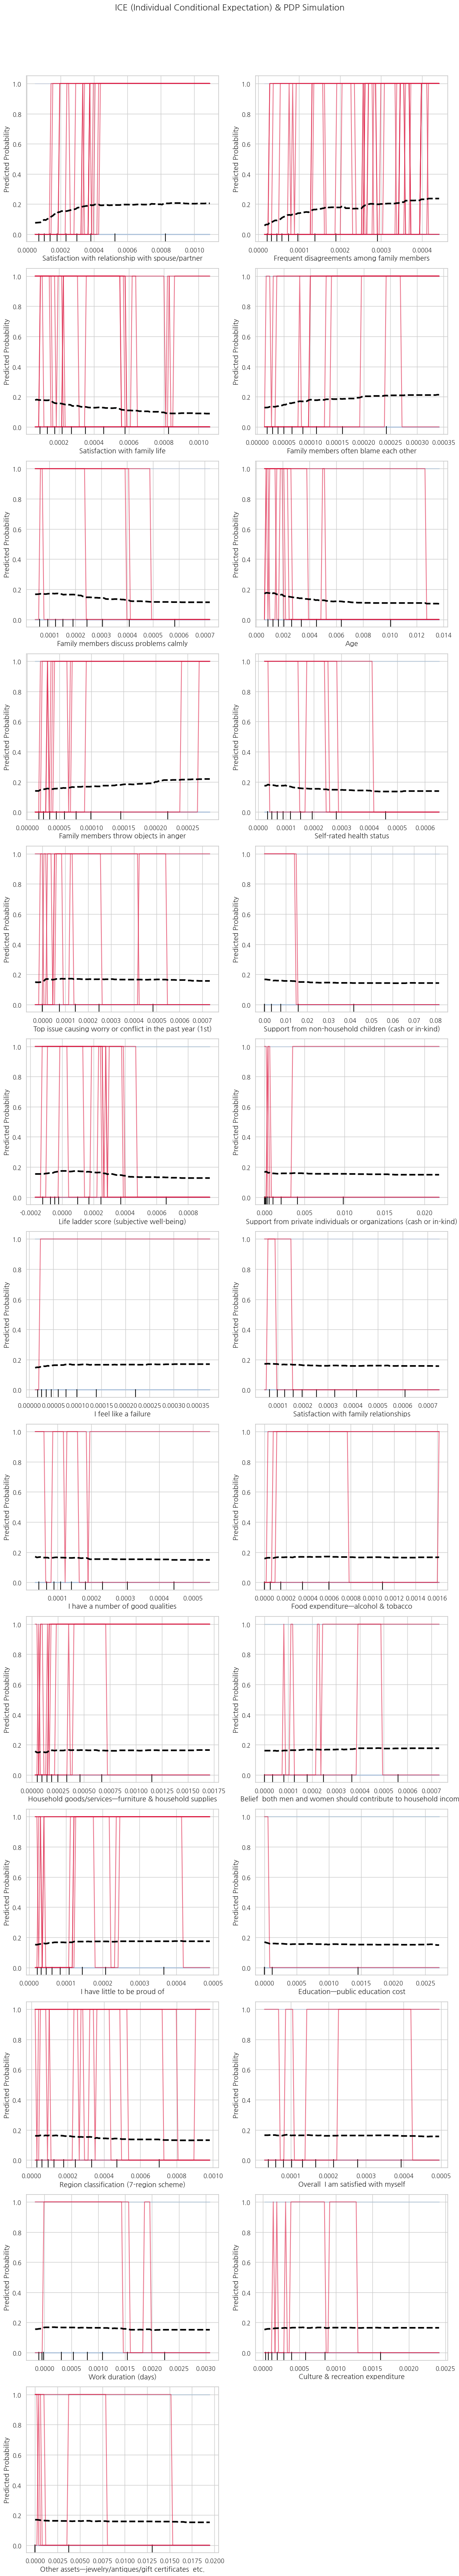


[Train Dataset Individual]: 2026-07-21 16:56:09.574641
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 24844


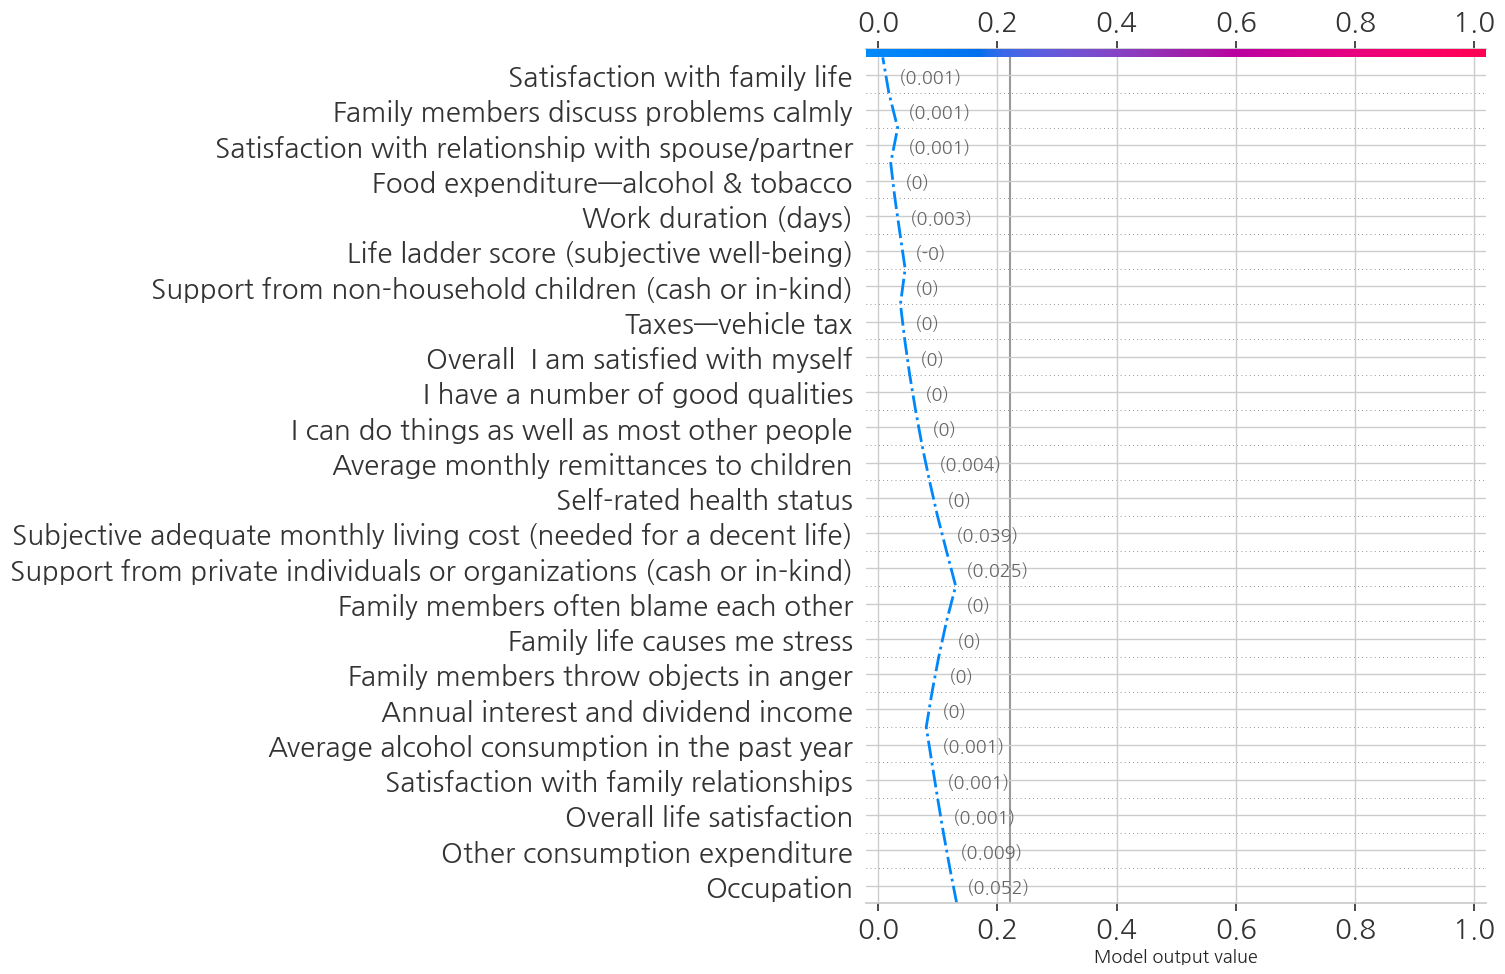


[Test Dataset Individual]: 2026-07-21 16:56:09.871260
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 7953


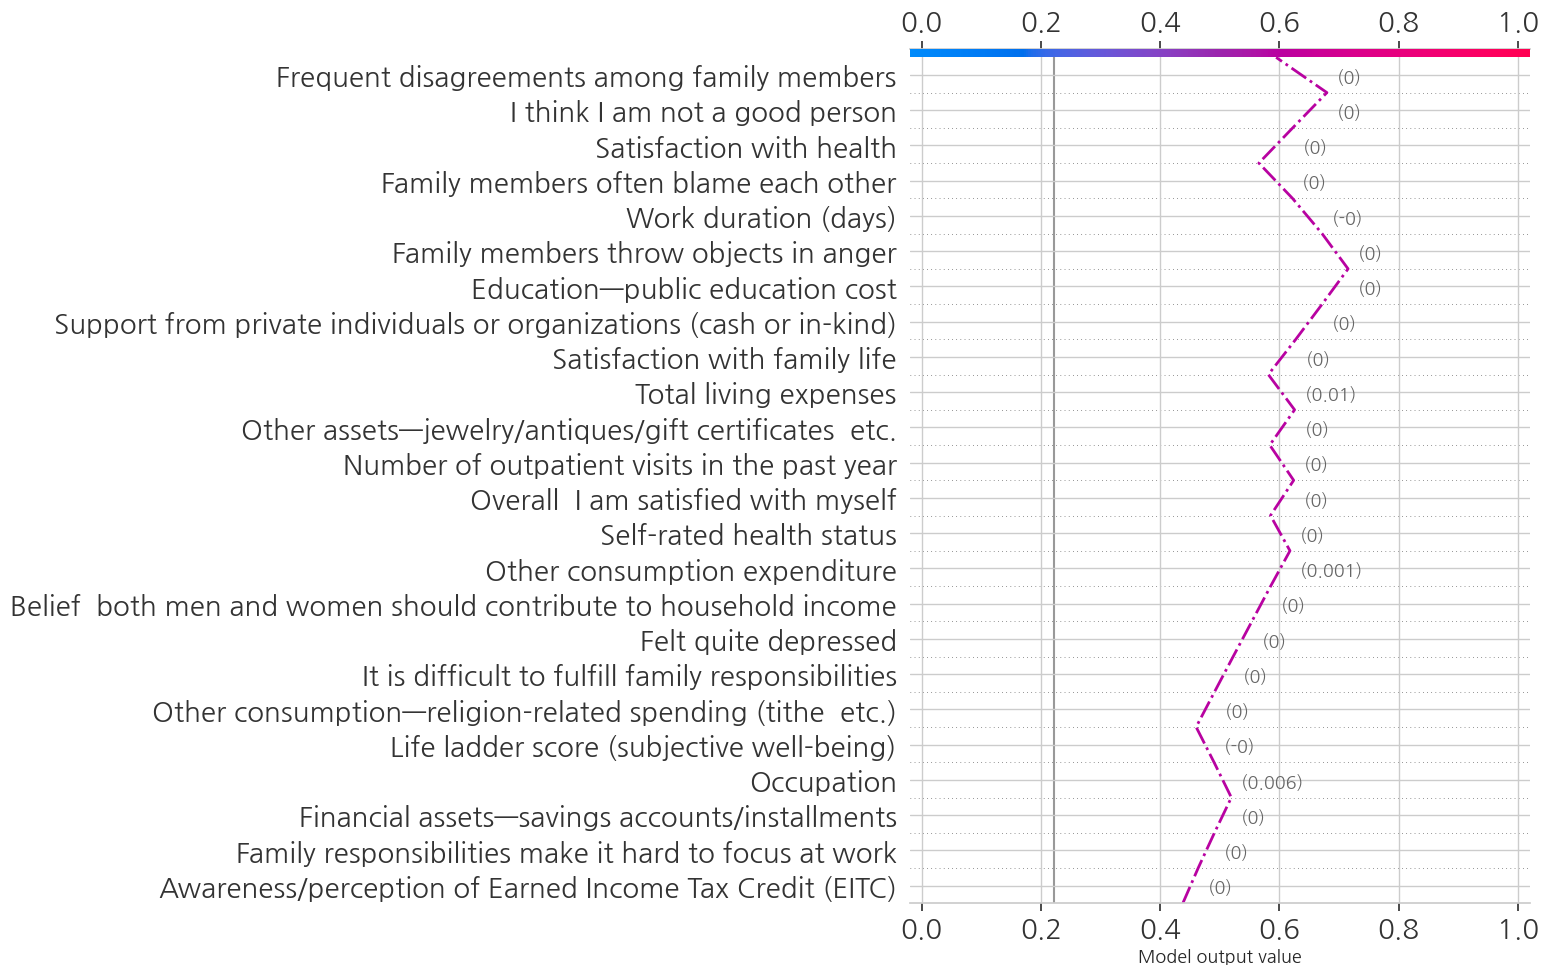

In [48]:
# Rename of Columns
X_selected = None
# df_domain_rename = pd.read_excel(os.path.join(FOLDER_GDM, '[Rename_20251228].xlsx'), sheet_name='Features_SI')
# df_domain_rename = {i[0]:i[1] for i in df_domain_rename[['변수설명(한글)', '변수설명(영어)']].values}
# if LANGUAGE == 'kr':
#     X_selected = [col for col in X_colname if col in list(df_domain_rename.keys())]
# else:
#     X_selected = [df_rename[col] for col in X_colname if col in list(df_domain_rename.keys())]

# SHAP 실행
explanation_SHAP(
    model=BEST_MODEL, 
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    X_colname=X_colname, X_selected=X_selected,
    interaction=INTERACTION,
    interaction_samples=INTERACTION_SAMPLES,
    interaction_batch=INTERACTION_BATCH,
    max_display=X_TOP_DISPLAY-25,
)


# Group Analysis

## Sex


★★★ Subgroup Performance (Fairness) Evaluation: [Sex] ★★★


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Sex,Male,10496,0.7678,0.6427,0.9568,0.6997,0.8997,0.7998,0.9053
1,Sex,Female,10965,0.7527,0.6622,0.9489,0.7046,0.8943,0.8055,0.8965



★★★ Subgroup Analysis Pipeline: 기준 변수 [Sex] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_XGBoost_20260716_091745.pkl
👉 [Success] Loaded SHAP value feature names have been updated in-memory!



################################################################################
🚀 실행 중인 데이터셋: [ Test Set ]
################################################################################

------------------------------------------------------------
### [Test Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 282.47it/s]



------------------------------------------------------------
### [Sex] - Male Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 10496명

[Male] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 513.51it/s]



[Male] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


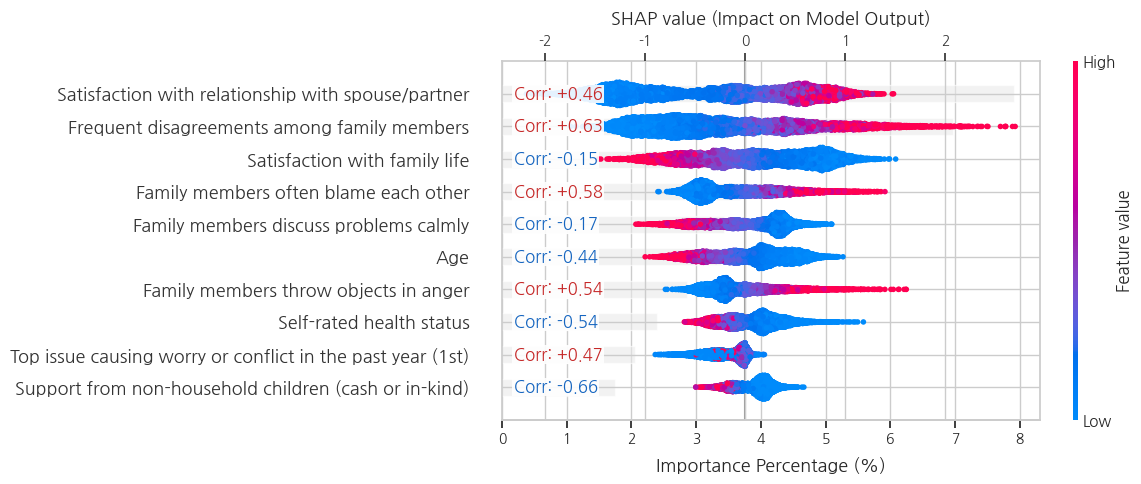

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 498.25it/s]



------------------------------------------------------------
### [Sex] - Female Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 10965명

[Female] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 505.39it/s]



[Female] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


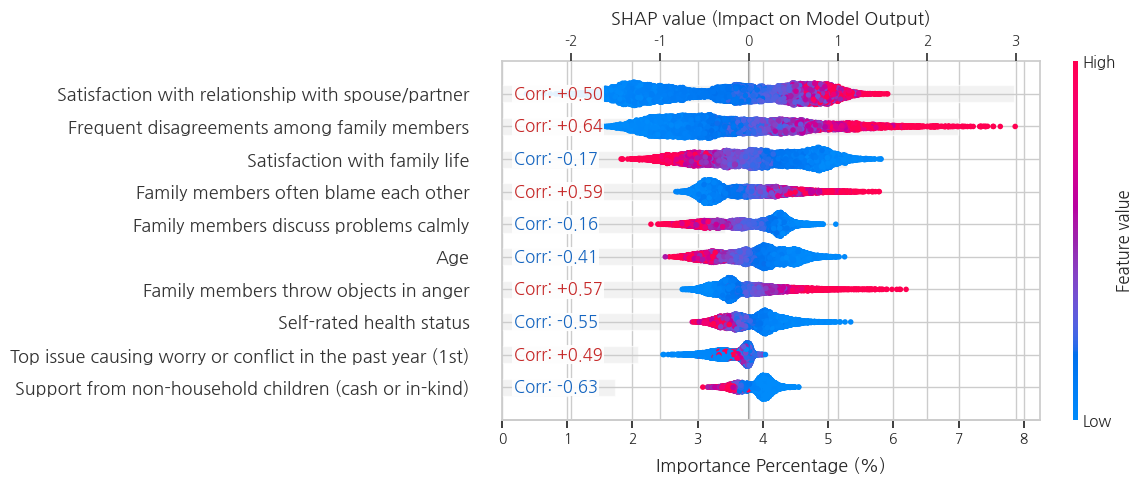

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 483.29it/s]


### Group Rank & Direction Master Table (Test Set, Split by: Sex) ###


,Feature,Rank_Total,DirectionPearson_Total,Directional Crach,Rank Reversal,Intensity Disparity
13,Satisfaction with family relationships,14,-0.0962,NaN,[1위차] Female(14) vs Male(15),NaN
14,I have a number of good qualities,15,-0.2690,NaN,[2위차] Male(14) vs Female(16),NaN
15,Food expenditure—alcohol & tobacco,16,0.5656,NaN,[1위차] Female(15) vs Male(16),NaN
18,I have little to be proud of,19,0.5754,NaN,[1위차] Male(19) vs Female(20),NaN
19,Education—public education cost,20,-0.4699,NaN,[1위차] Female(19) vs Male(20),NaN
20,Region classification (7-region scheme),21,-0.3826,NaN,[1위차] Male(21) vs Female(22),NaN
21,Overall I am satisfied with myself,22,-0.2001,NaN,[1위차] Male(22) vs Female(23),NaN
22,Work duration (days),23,-0.0301,NaN,[2위차] Female(21) vs Male(23),NaN
26,I think I am not a good person,27,0.3117,NaN,[2위차] Male(27) vs Female(29),NaN
28,Family responsibilities make it hard to focus at work,29,-0.5900,NaN,[3위차] Female(27) vs Male(30),NaN



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Test Set)


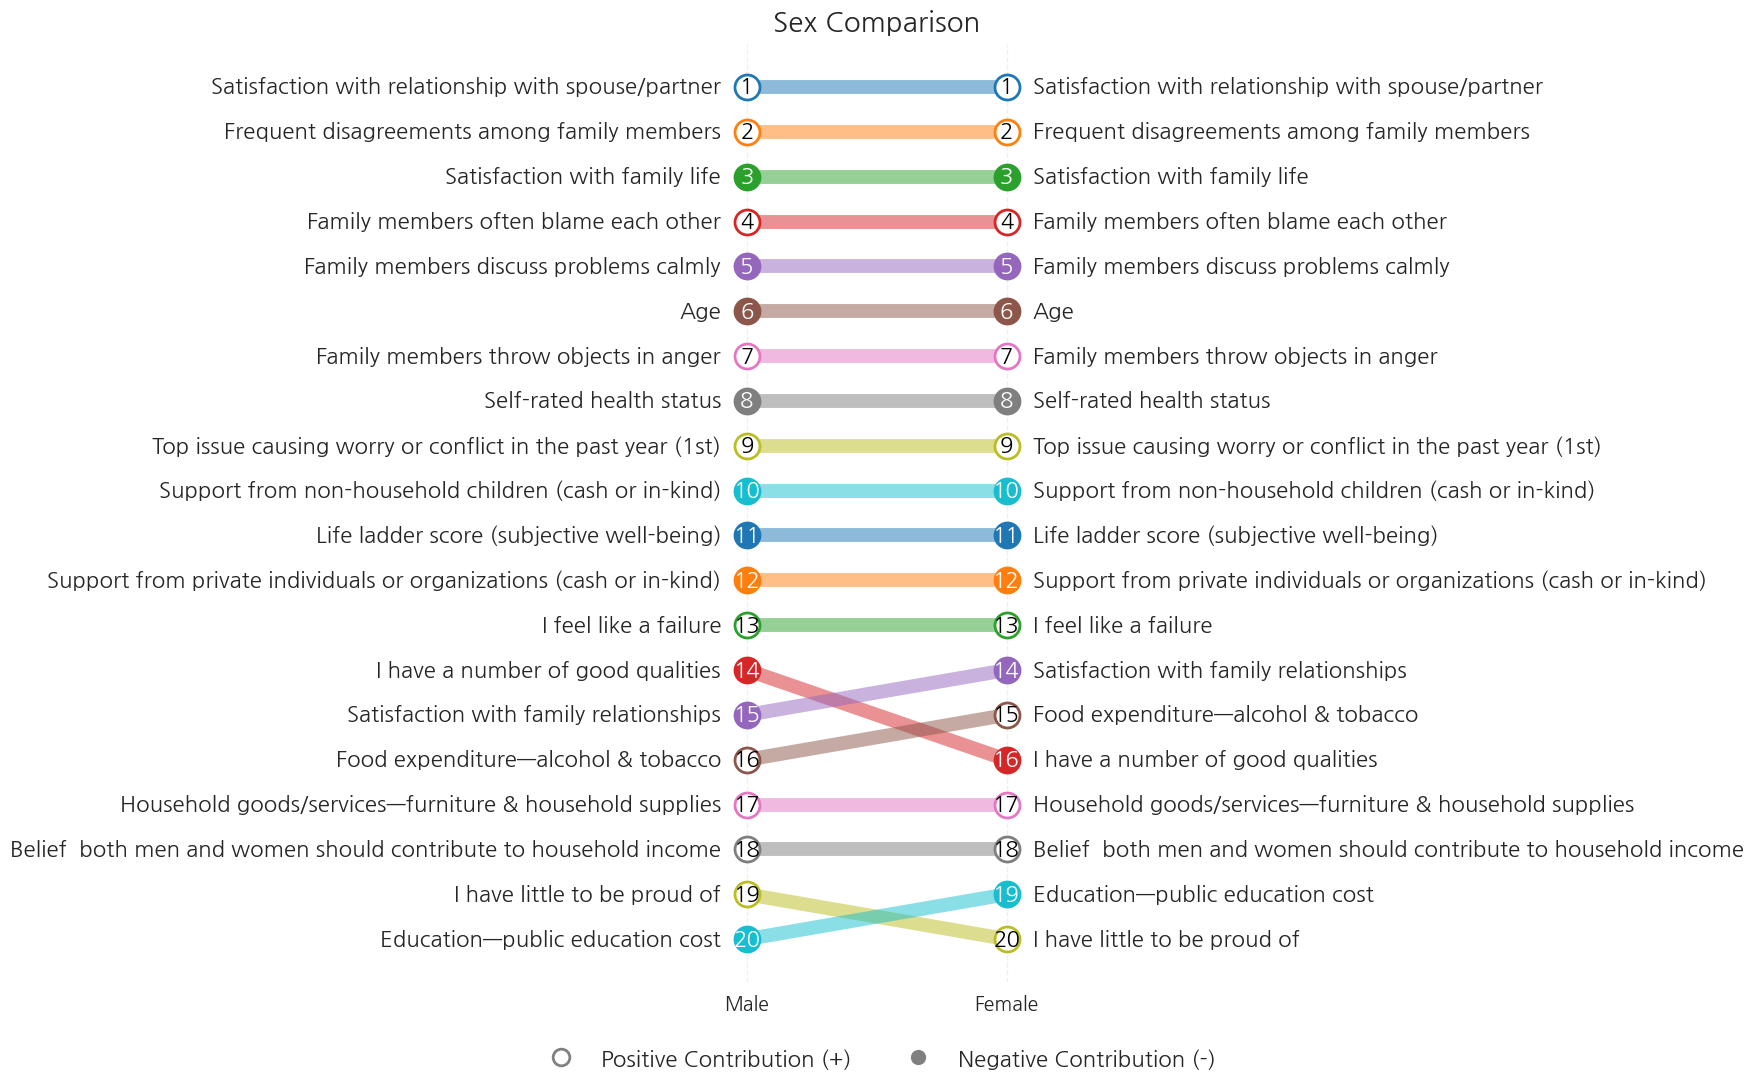


마스터 테이블이 저장되었습니다: /mnt/c/DataScience/Publication/202402_IPVPrediction/Result/FeatureImportance_XGBoost_Test_Sex.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [27]:
# Sex
target_group = 'Sex'
groups = {'Male': 1, 
          'Female': 2}
key_features=None
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]

df_fairness_cash = evaluation_class_GroupFairness(
    best_model=BEST_MODEL,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
)

df_comp_train_cash, df_comp_test_cash = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test,
    X_colname=X_colname,
    best_algo=BEST_ALGO,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

## Age


★★★ Subgroup Performance (Fairness) Evaluation: [Age] ★★★


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Age,Youth,1508,0.7656,0.6384,0.9500,0.6963,0.8866,0.7942,0.8896
1,Age,Middle-aged,12386,0.7631,0.6643,0.9468,0.7103,0.8888,0.8055,0.8970
2,Age,Senior,7567,0.7505,0.6315,0.9625,0.6859,0.9123,0.7970,0.9074



★★★ Subgroup Analysis Pipeline: 기준 변수 [Age] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_XGBoost_20260716_091745.pkl
👉 [Success] Loaded SHAP value feature names have been updated in-memory!



################################################################################
🚀 실행 중인 데이터셋: [ Test Set ]
################################################################################

------------------------------------------------------------
### [Test Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 277.86it/s]



------------------------------------------------------------
### [Age] - Youth Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 1508명

[Youth] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|████████████████████████████████████████████████████| 108/108 [00:00<00:00, 1357.88it/s]



[Youth] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


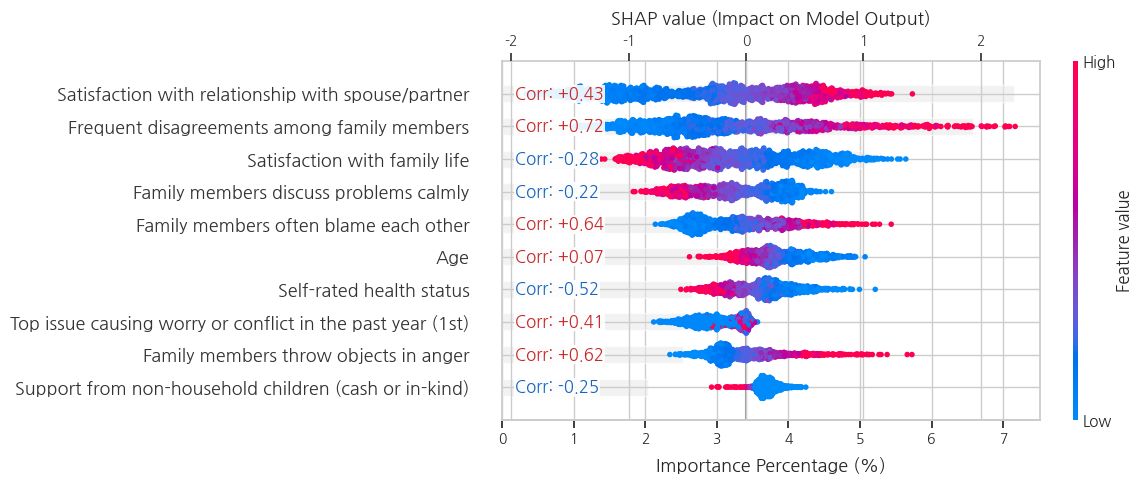

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|████████████████████████████████████████████████████| 108/108 [00:00<00:00, 1227.54it/s]


------------------------------------------------------------
### [Age] - Middle-aged Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 12386명

[Middle-aged] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...


Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 465.52it/s]



[Middle-aged] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


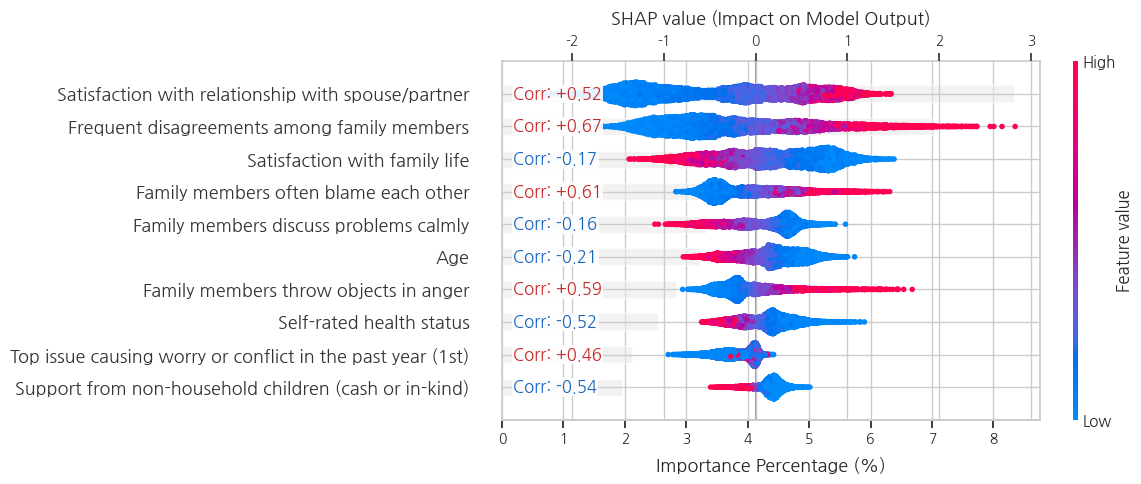

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 458.84it/s]



------------------------------------------------------------
### [Age] - Senior Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 7567명

[Senior] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 654.36it/s]



[Senior] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


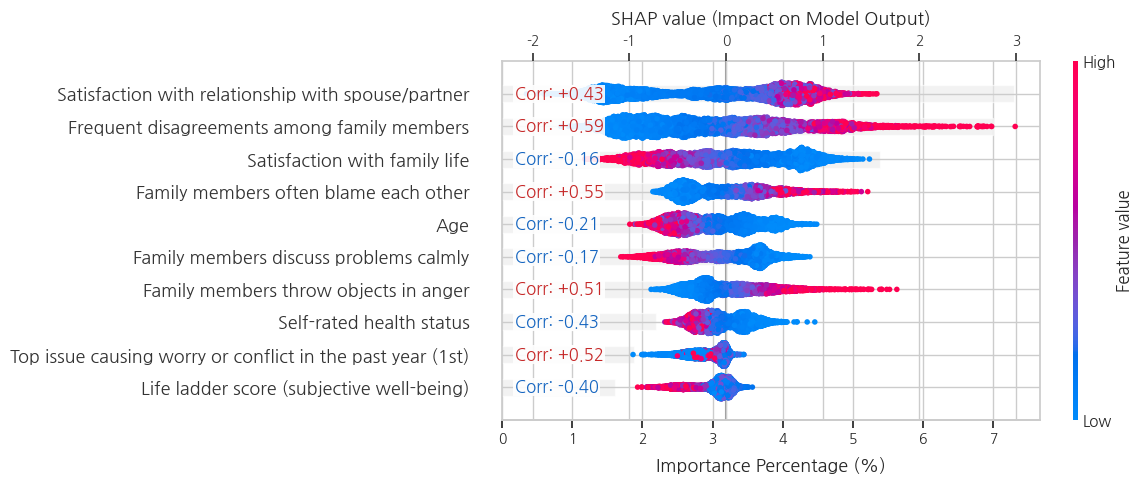

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 679.36it/s]


### Group Rank & Direction Master Table (Test Set, Split by: Age) ###


,Feature,Rank_Total,DirectionPearson_Total,Directional Crach,Rank Reversal,Intensity Disparity
2,Satisfaction with family life,3,-0.1625,NaN,NaN,Youth vs Middle-aged 격차(0.112)
5,Age,6,-0.4240,Youth(+) vs Middle-aged(-) vs Senior(-),NaN,Youth vs Middle-aged 격차(0.147)
9,Support from non-household children (cash or in-kind),10,-0.6423,NaN,NaN,Youth vs Middle-aged 격차(0.288)
10,Life ladder score (subjective well-being),11,-0.3331,NaN,NaN,Youth vs Middle-aged 격차(0.113) | Middle-aged vs Senior 격차(0.111)
11,Support from private individuals or organizations (cash or in-kind),12,-0.4561,NaN,[4위차] Middle-aged(16) vs Youth(20) | [5위차] Senior(11) vs Middle-aged(16),NaN
12,I feel like a failure,13,0.5803,NaN,[12위차] Middle-aged(13) vs Youth(25) | [3위차] Middle-aged(13) vs Senior(16),NaN
13,Satisfaction with family relationships,14,-0.0962,NaN,[5위차] Middle-aged(14) vs Youth(19) | [6위차] Middle-aged(14) vs Senior(20),NaN
14,I have a number of good qualities,15,-0.2690,NaN,[7위차] Middle-aged(15) vs Senior(22),NaN
15,Food expenditure—alcohol & tobacco,16,0.5656,NaN,[5위차] Youth(14) vs Middle-aged(19) | [4위차] Senior(15) vs Middle-aged(19),NaN
16,Household goods/services—furniture & household supplies,17,0.3156,NaN,[17위차] Middle-aged(18) vs Youth(35) | [4위차] Senior(14) vs Middle-aged(18),NaN



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Test Set)


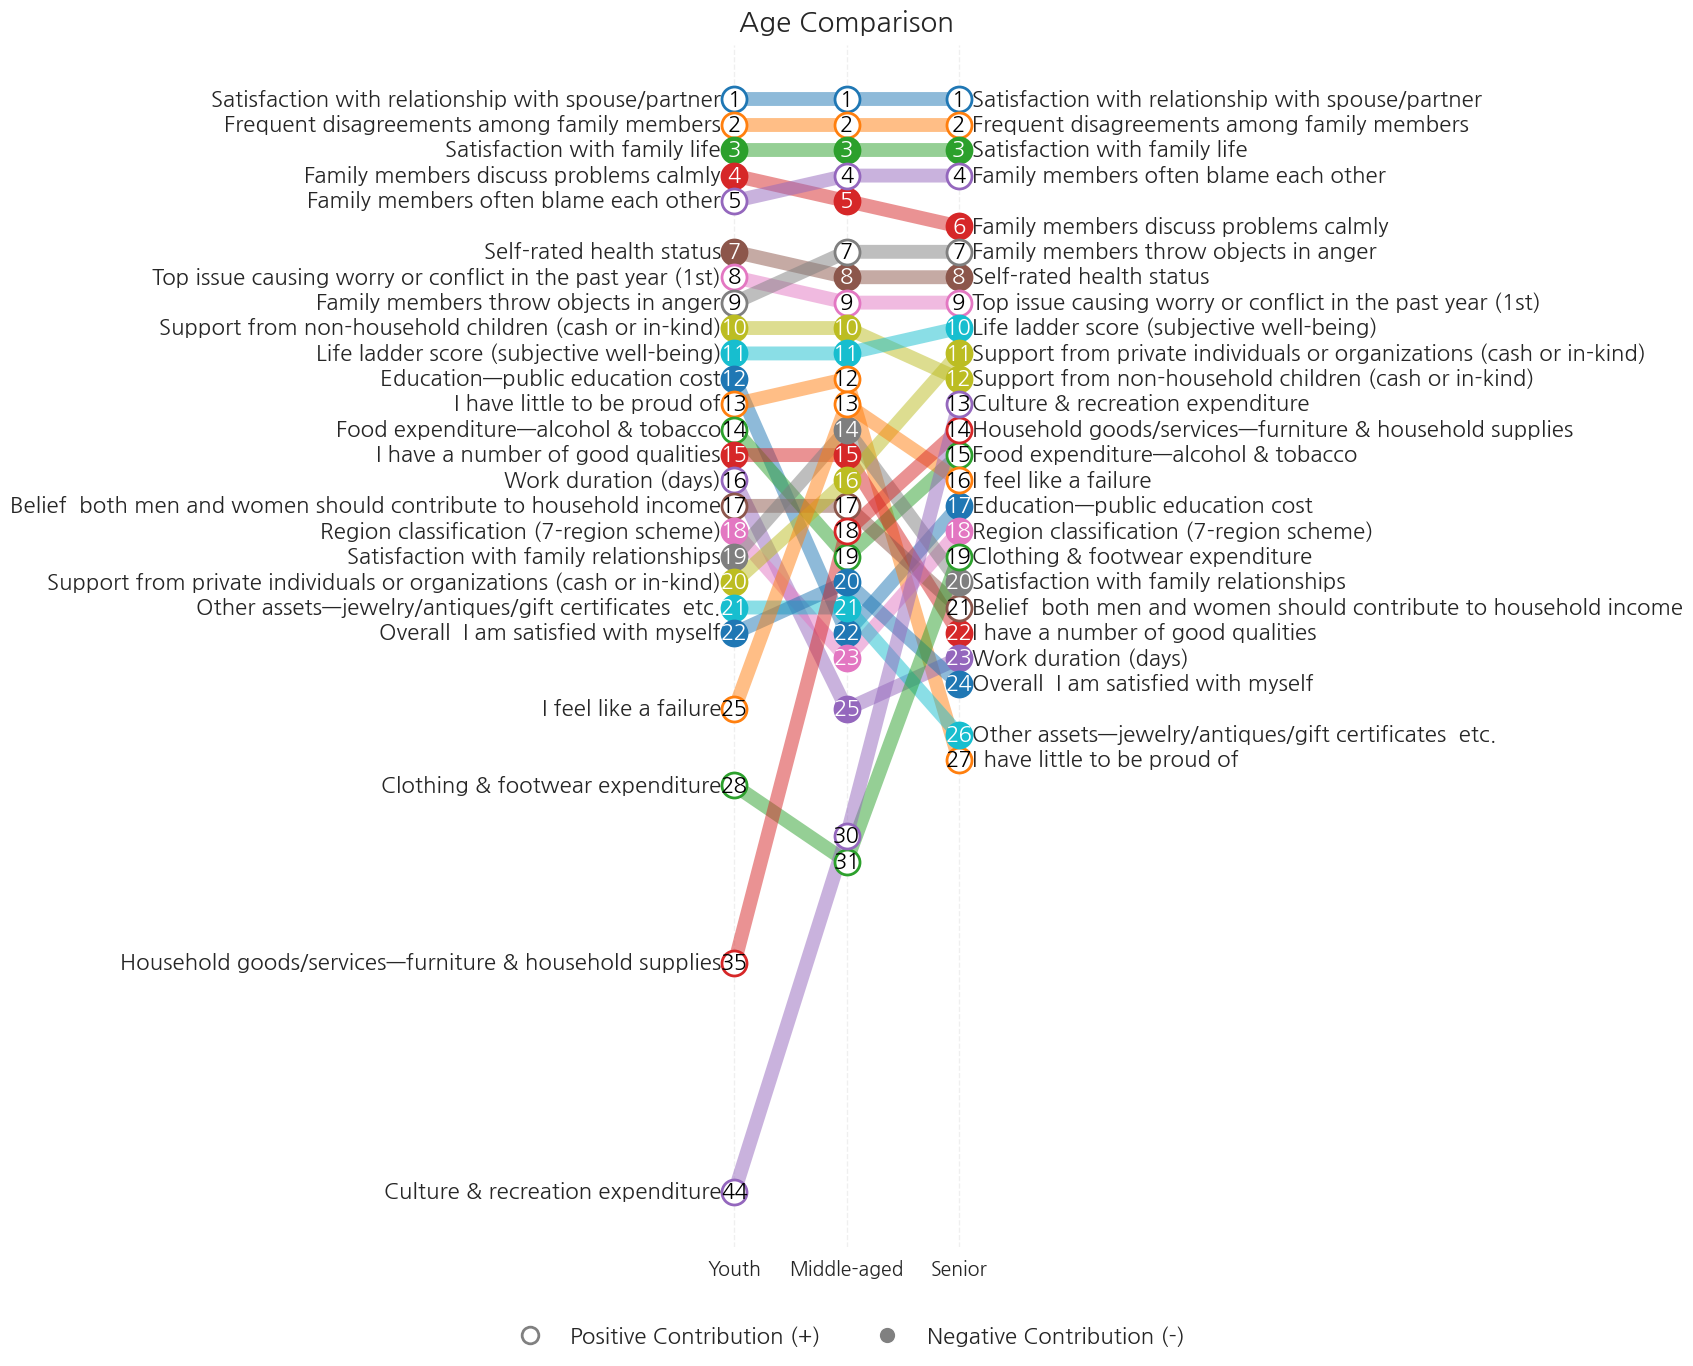


마스터 테이블이 저장되었습니다: /mnt/c/DataScience/Publication/202402_IPVPrediction/Result/FeatureImportance_XGBoost_Test_Age.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [35]:
# Age
target_group = 'Age'
groups = {
    'Youth': lambda x: x < 35, 
    'Middle-aged': lambda x: (x >= 35) & (x < 65), 
    'Senior': lambda x: x >= 65
}
key_features=None
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]

df_fairness_cash = evaluation_class_GroupFairness(
    best_model=BEST_MODEL,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
)

df_comp_train_cash, df_comp_test_cash = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test,
    X_colname=X_colname,
    best_algo=BEST_ALGO,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

## Disposable Income


★★★ Subgroup Performance (Fairness) Evaluation: [Disposable income] ★★★


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Disposable income,Low,5365,0.7337,0.6831,0.9462,0.7075,0.8993,0.8147,0.9073
1,Disposable income,Middle,10707,0.7613,0.6498,0.9494,0.7011,0.8898,0.7996,0.8992
2,Disposable income,High,5389,0.7879,0.6286,0.9656,0.6993,0.9087,0.7971,0.8963



★★★ Subgroup Analysis Pipeline: 기준 변수 [Disposable income] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_XGBoost_20260716_091745.pkl
👉 [Success] Loaded SHAP value feature names have been updated in-memory!



################################################################################
🚀 실행 중인 데이터셋: [ Test Set ]
################################################################################

------------------------------------------------------------
### [Test Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 277.86it/s]



------------------------------------------------------------
### [Disposable income] - Low Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 5365명

[Low] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 751.69it/s]



[Low] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


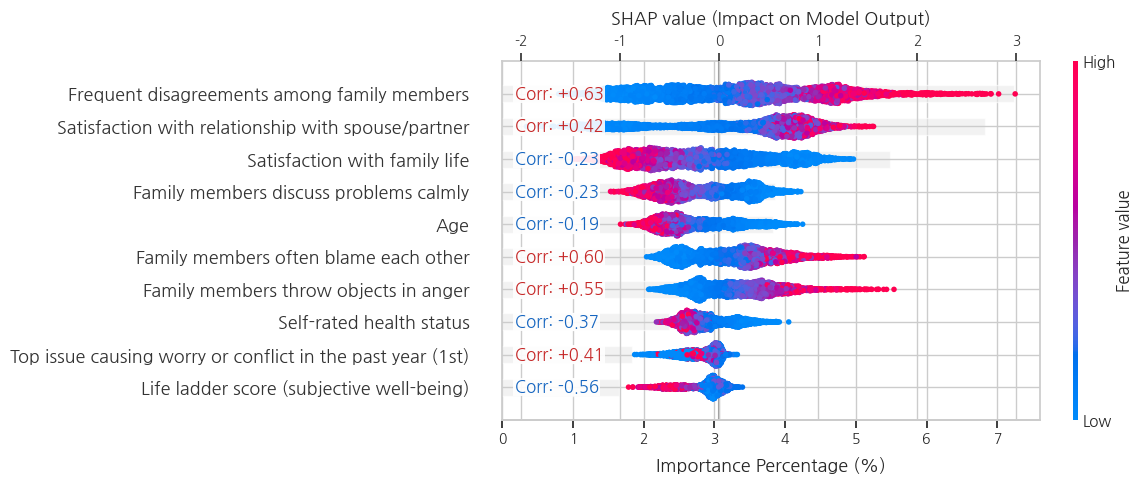

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 809.98it/s]


------------------------------------------------------------
### [Disposable income] - Middle Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 10707명



[Middle] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 483.08it/s]



[Middle] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


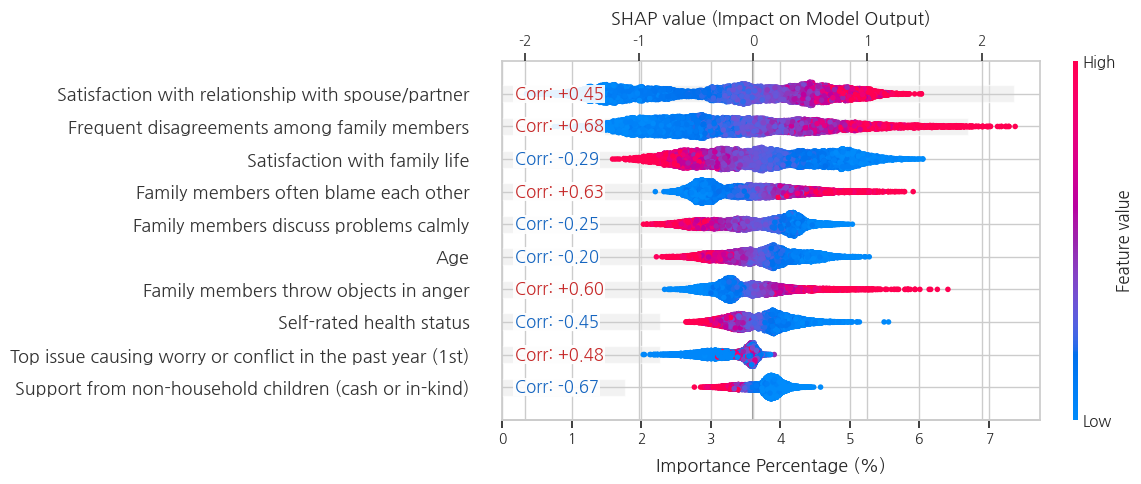

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 511.08it/s]



------------------------------------------------------------
### [Disposable income] - High Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 5389명

[High] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 811.48it/s]


[High] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


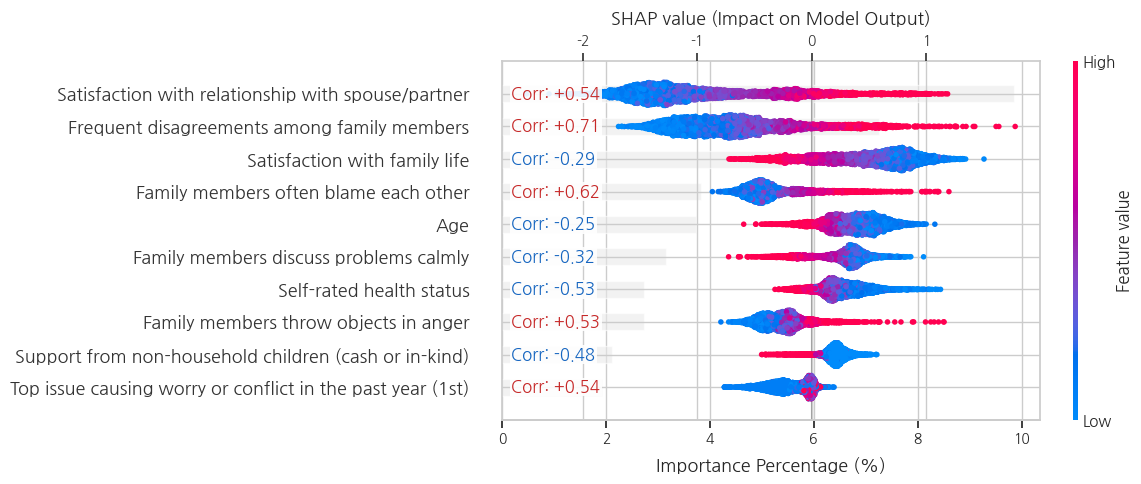

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 808.37it/s]


### Group Rank & Direction Master Table (Test Set, Split by: Disposable income) ###


,Feature,Rank_Total,DirectionPearson_Total,Directional Crach,Rank Reversal,Intensity Disparity
0,Satisfaction with relationship with spouse/partner,1,0.4836,NaN,[1위차] Middle(1) vs Low(2) | [1위차] High(1) vs Low(2),"Low vs High 크기 격차 현저 (Gap: 0.125 / Low=0.416, High=0.541)"
1,Frequent disagreements among family members,2,0.6357,NaN,[1위차] Low(1) vs Middle(2) | [1위차] Low(1) vs High(2),NaN
3,Family members often blame each other,4,0.5849,NaN,[2위차] Middle(4) vs Low(6) | [2위차] High(4) vs Low(6),NaN
4,Family members discuss problems calmly,5,-0.1604,NaN,[1위차] Low(4) vs Middle(5) | [2위차] Low(4) vs High(6) | [1위차] Middle(5) vs High(6),NaN
5,Age,6,-0.4240,NaN,[1위차] Low(5) vs Middle(6) | [1위차] High(5) vs Middle(6),NaN
6,Family members throw objects in anger,7,0.5523,NaN,[1위차] Low(7) vs High(8) | [1위차] Middle(7) vs High(8),NaN
7,Self-rated health status,8,-0.5455,NaN,[1위차] High(7) vs Low(8) | [1위차] High(7) vs Middle(8),"Low vs High 크기 격차 현저 (Gap: 0.156 / Low=-0.374, High=-0.530)"
8,Top issue causing worry or conflict in the past year (1st),9,0.4773,NaN,[1위차] Low(9) vs High(10) | [1위차] Middle(9) vs High(10),"Low vs High 크기 격차 현저 (Gap: 0.128 / Low=0.413, High=0.541)"
9,Support from non-household children (cash or in-kind),10,-0.6423,NaN,[4위차] Middle(10) vs Low(14) | [5위차] High(9) vs Low(14) | [1위차] High(9) vs Middle(10),"Low vs High 크기 격차 현저 (Gap: 0.206 / Low=-0.686, High=-0.480) | Middle vs High 크기 격차 현저 (Gap: 0.19..."
10,Life ladder score (subjective well-being),11,-0.3331,NaN,[1위차] Low(10) vs Middle(11) | [16위차] Low(10) vs High(26) | [15위차] Middle(11) vs High(26),"Low vs Middle 크기 격차 현저 (Gap: 0.144 / Low=-0.558, Middle=-0.414) | Low vs High 크기 격차 현저 (Gap: 0.3..."



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Test Set)


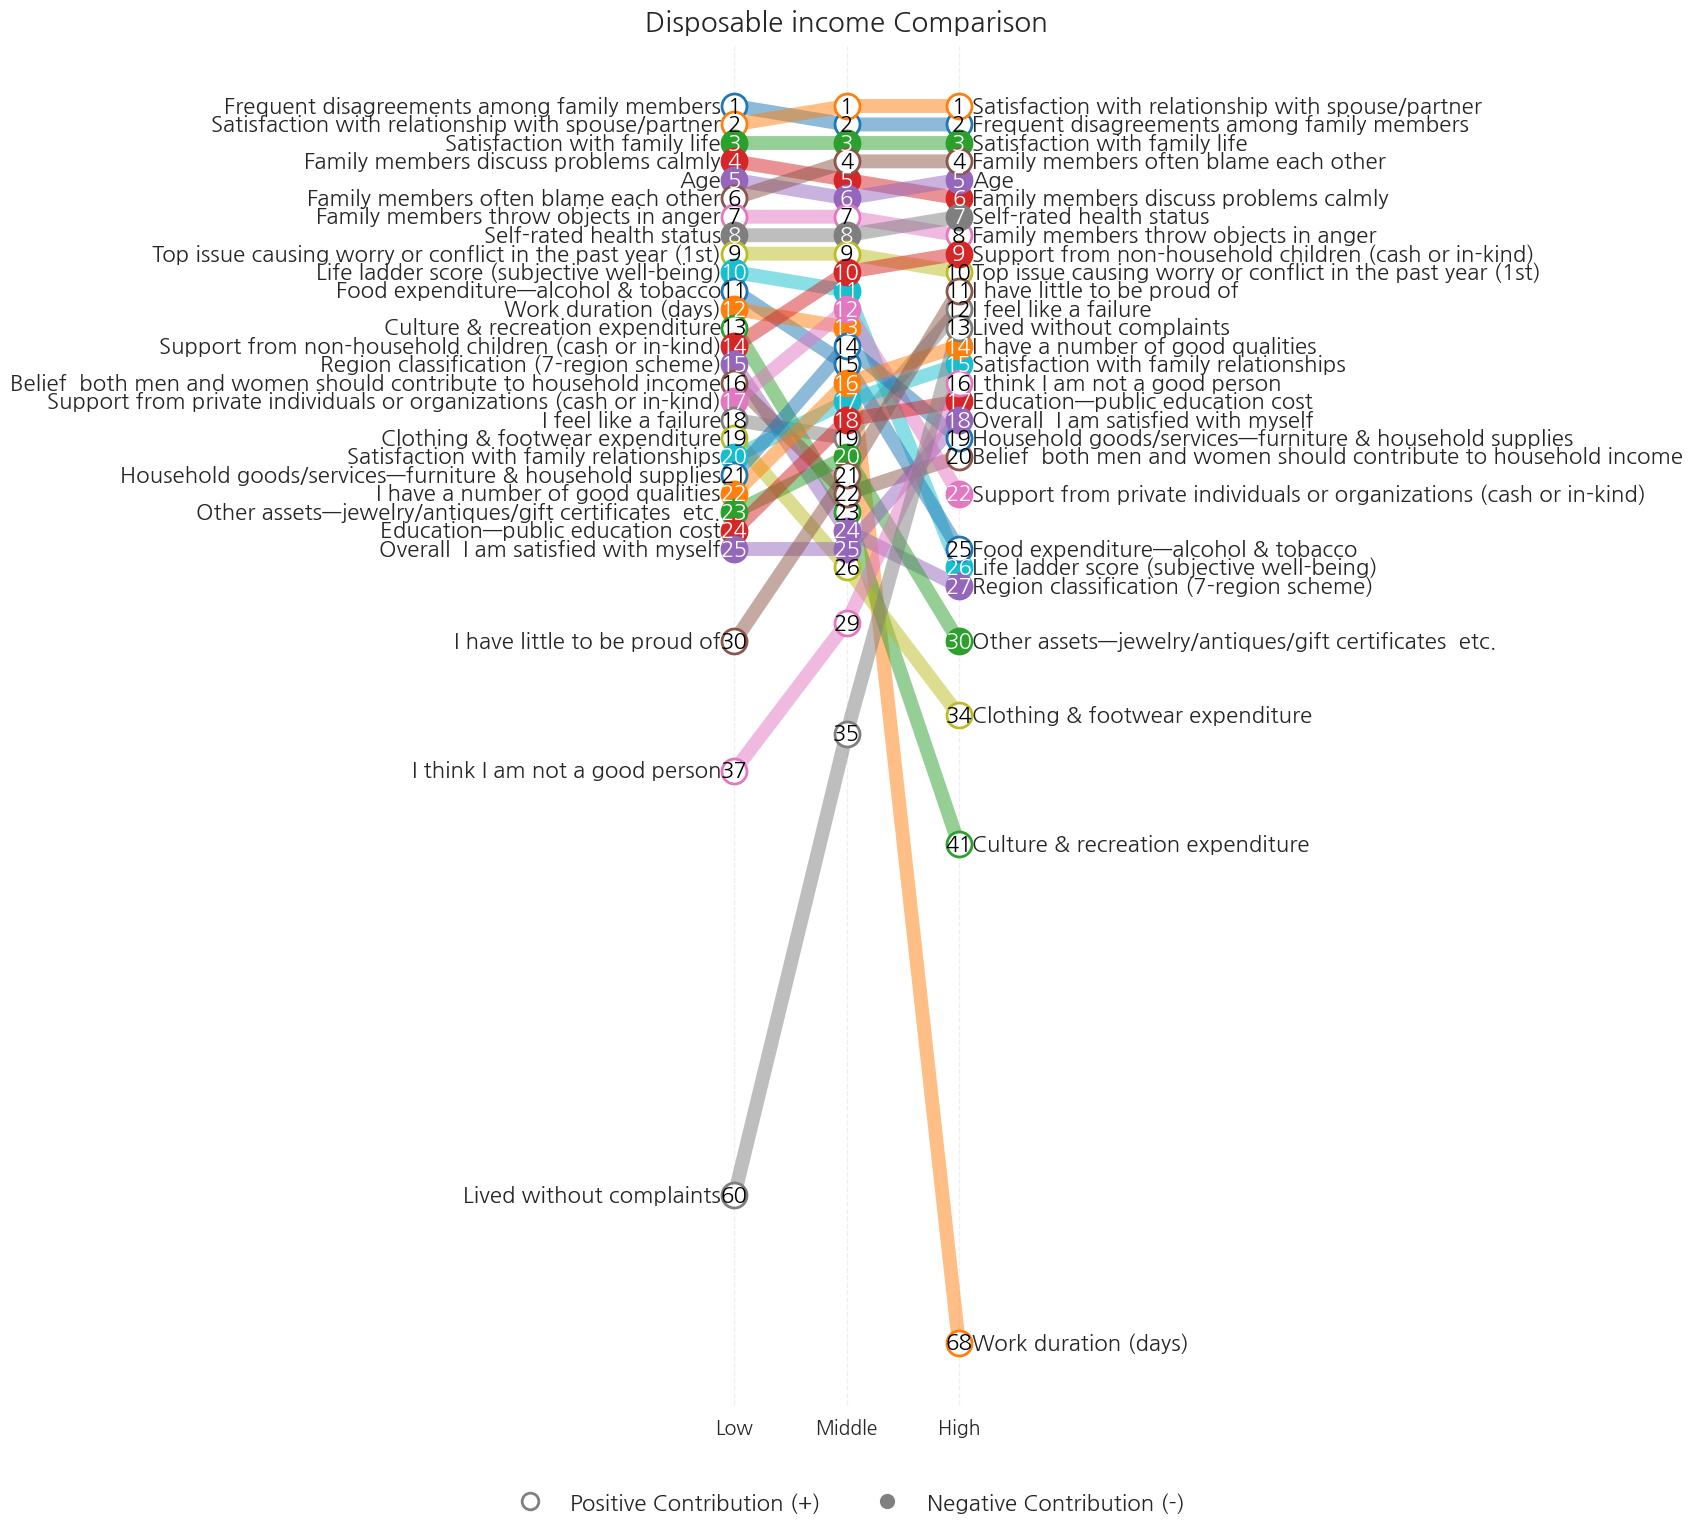


마스터 테이블이 저장되었습니다: /mnt/c/DataScience/Publication/202402_IPVPrediction/Result/FeatureImportance_XGBoost_Test_Disposable income.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [31]:
# Income
target_group = 'Disposable income'
groups = {
    'Low': lambda x: x < df_final[target_group].quantile(0.25),
    'Middle': lambda x: (x >= df_final[target_group].quantile(0.25)) & (x < df_final[target_group].quantile(0.75)),
    'High': lambda x: x >= df_final[target_group].quantile(0.75)
}
key_features=None
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness_cash = evaluation_class_GroupFairness(
    best_model=BEST_MODEL,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
)

df_comp_train_cash, df_comp_test_cash = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test,
    X_colname=X_colname,
    best_algo=BEST_ALGO,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

## Health


★★★ Subgroup Performance (Fairness) Evaluation: [Self-rated health status] ★★★


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Self-rated health status,Low (<Q1),2083,0.8345,0.7474,0.9557,0.7885,0.9078,0.8516,0.9222
1,Self-rated health status,Non-Low (>=Q1),19378,0.7491,0.6400,0.9525,0.6903,0.8958,0.7962,0.8978



★★★ Subgroup Analysis Pipeline: 기준 변수 [Self-rated health status] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_XGBoost_20260716_091745.pkl
👉 [Success] Loaded SHAP value feature names have been updated in-memory!



################################################################################
🚀 실행 중인 데이터셋: [ Test Set ]
################################################################################

------------------------------------------------------------
### [Test Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 290.72it/s]



------------------------------------------------------------
### [Self-rated health status] - Low (<Q1) Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 2083명

[Low (<Q1)] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|████████████████████████████████████████████████████| 108/108 [00:00<00:00, 1235.98it/s]



[Low (<Q1)] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


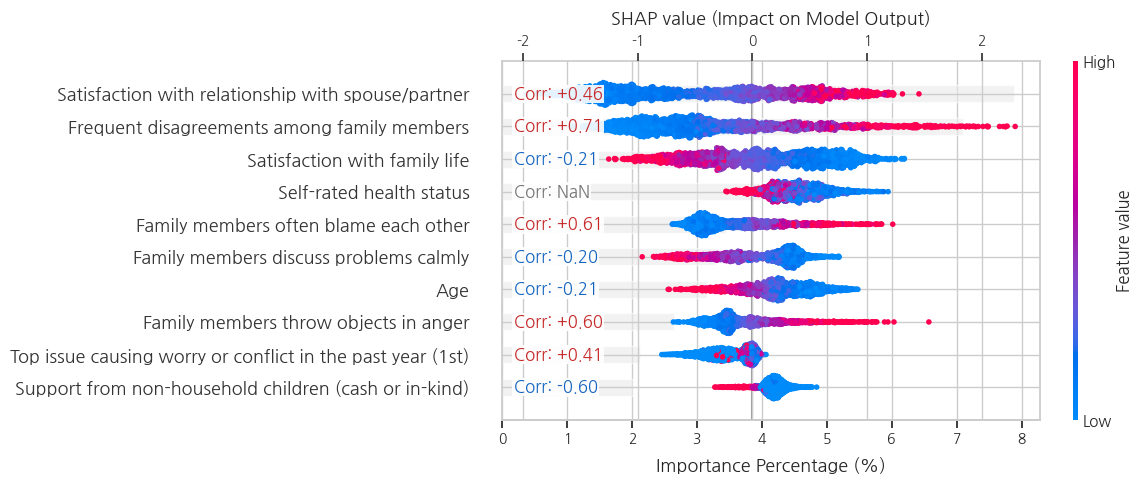

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|████████████████████████████████████████████████████| 108/108 [00:00<00:00, 1227.92it/s]


------------------------------------------------------------
### [Self-rated health status] - Non-Low (>=Q1) Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 19378명



[Non-Low (>=Q1)] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 303.34it/s]



[Non-Low (>=Q1)] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


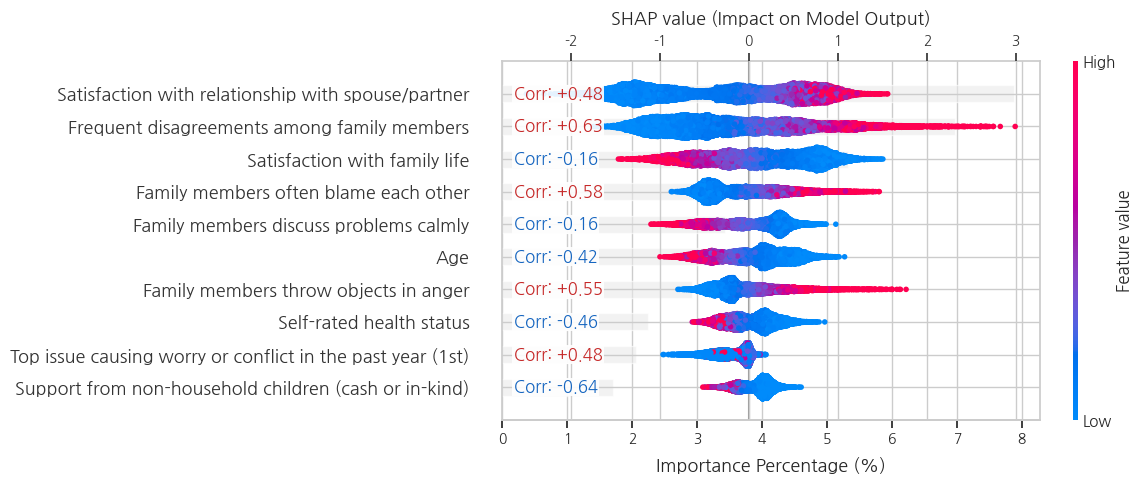

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 319.14it/s]


### Group Rank & Direction Master Table (Test Set, Split by: Self-rated health status) ###


,Feature,Rank_Total,DirectionPearson_Total,Directional Crach,Rank Reversal,Intensity Disparity
5,Age,6,-0.4240,NaN,NaN,Low (<Q1) vs Non-Low (>=Q1) 격차(0.215)
7,Self-rated health status,8,-0.5455,NaN,[4위차] Low (<Q1)(4) vs Non-Low (>=Q1)(8),Low (<Q1) vs Non-Low (>=Q1) 격차(0.457)
11,Support from private individuals or organizations (cash or in-kind),12,-0.4561,NaN,[8위차] Non-Low (>=Q1)(12) vs Low (<Q1)(20),NaN
12,I feel like a failure,13,0.5803,NaN,[9위차] Non-Low (>=Q1)(13) vs Low (<Q1)(22),Low (<Q1) vs Non-Low (>=Q1) 격차(0.126)
13,Satisfaction with family relationships,14,-0.0962,NaN,[5위차] Non-Low (>=Q1)(14) vs Low (<Q1)(19),NaN
14,I have a number of good qualities,15,-0.2690,NaN,[3위차] Low (<Q1)(14) vs Non-Low (>=Q1)(17),NaN
16,Household goods/services—furniture & household supplies,17,0.3156,NaN,[11위차] Non-Low (>=Q1)(15) vs Low (<Q1)(26),NaN
17,Belief both men and women should contribute to household income,18,0.5340,NaN,[5위차] Low (<Q1)(13) vs Non-Low (>=Q1)(18),NaN
18,I have little to be proud of,19,0.5754,NaN,[8위차] Low (<Q1)(12) vs Non-Low (>=Q1)(20),NaN
19,Education—public education cost,20,-0.4699,NaN,[4위차] Low (<Q1)(15) vs Non-Low (>=Q1)(19),NaN



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Test Set)


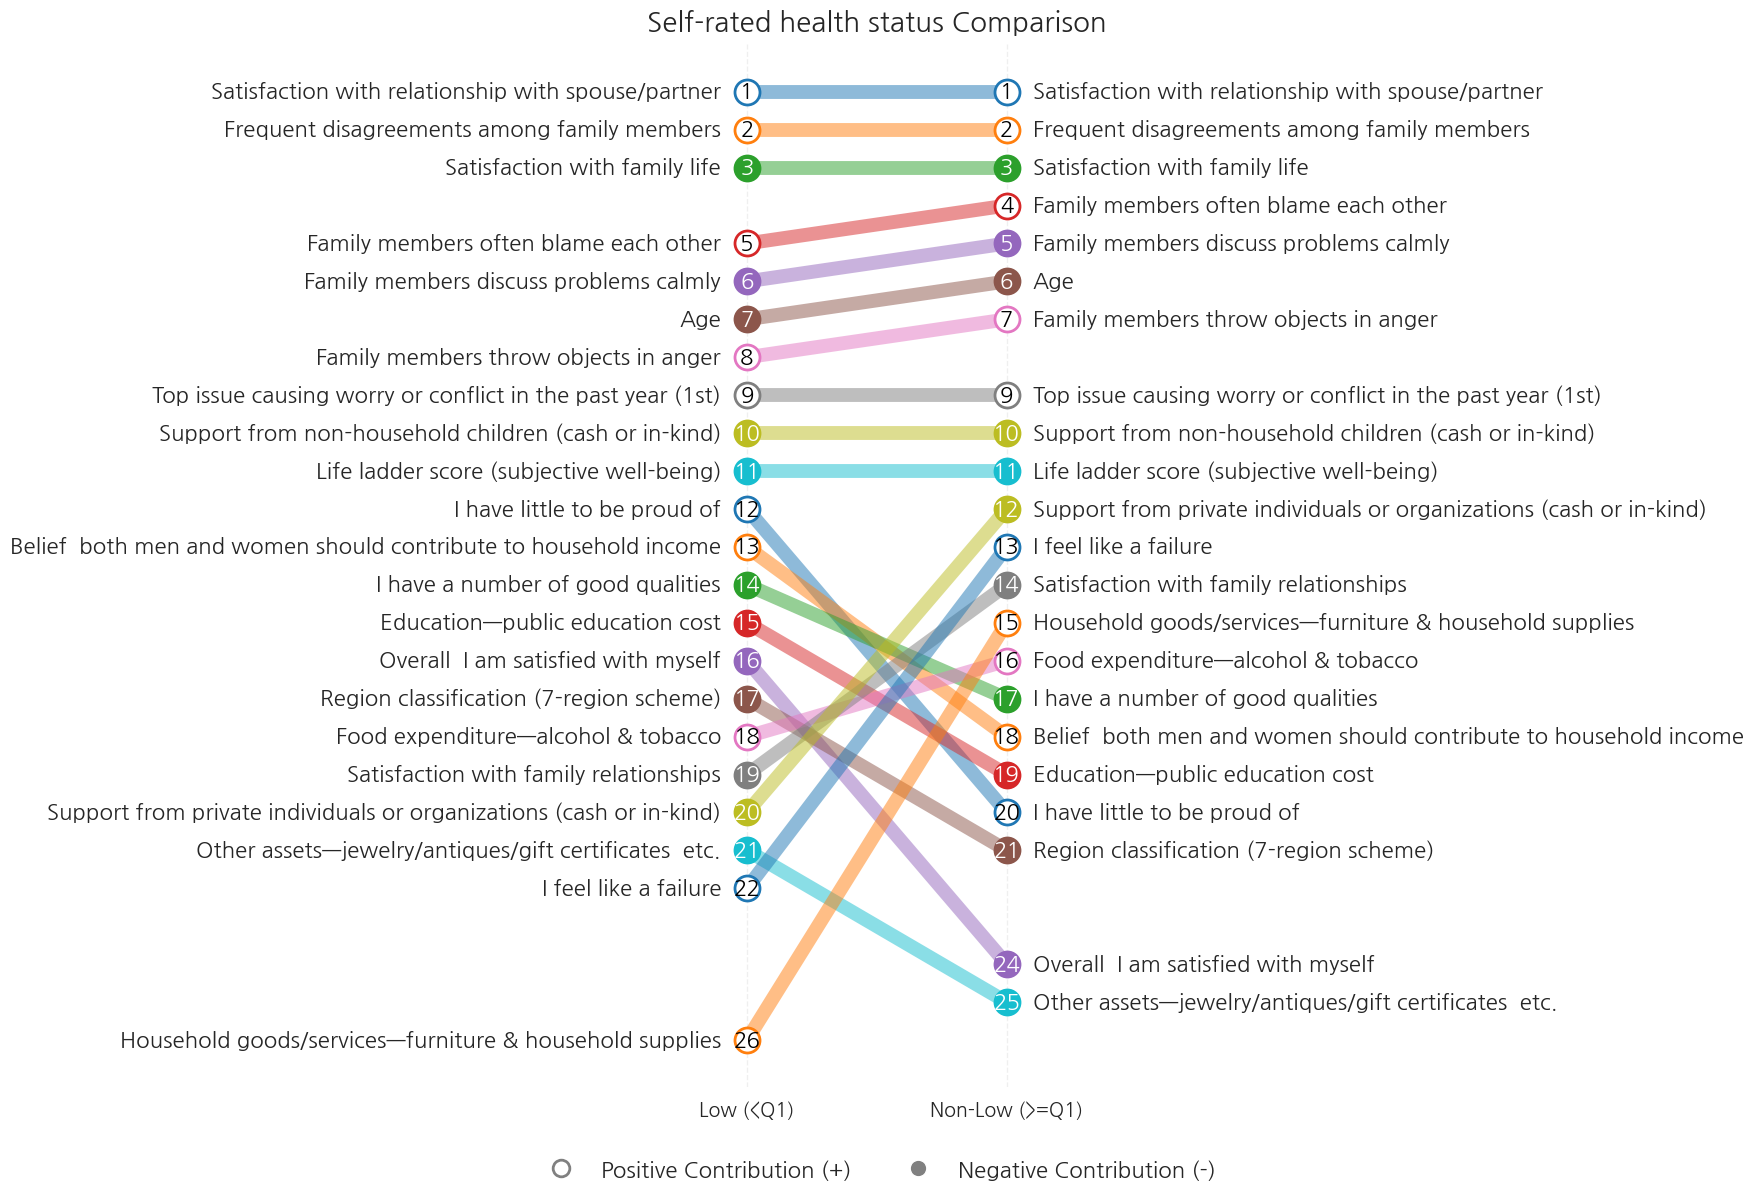


마스터 테이블이 저장되었습니다: /mnt/c/DataScience/Publication/202402_IPVPrediction/Result/FeatureImportance_XGBoost_Test_Self-rated health status.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [40]:
# Disease1
target_group = 'Self-rated health status' # 'Satisfaction with health' (Second Priority)
groups = {
    'Low (<Q1)': lambda x: x < df_final[target_group].quantile(0.25),
    # 'Middle (Q1-Q3)': lambda x: (x >= df_final[target_group].quantile(0.25)) & (x < df_final[target_group].quantile(0.75)),
    'Non-Low (>=Q1)': lambda x: x >= df_final[target_group].quantile(0.25)
}
key_features=None
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness_cash = evaluation_class_GroupFairness(
    best_model=BEST_MODEL,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
)

df_comp_train_cash, df_comp_test_cash = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test,
    X_colname=X_colname,
    best_algo=BEST_ALGO,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

## Housing


★★★ Subgroup Performance (Fairness) Evaluation: [Housing type] ★★★


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Housing type,Non-Apartment,12382,0.7553,0.6617,0.9502,0.7054,0.8959,0.8060,0.9048
1,Housing type,Apartment,9079,0.7664,0.6406,0.9562,0.6979,0.8983,0.7984,0.8951



★★★ Subgroup Analysis Pipeline: 기준 변수 [Housing type] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_XGBoost_20260716_091745.pkl
👉 [Success] Loaded SHAP value feature names have been updated in-memory!



################################################################################
🚀 실행 중인 데이터셋: [ Test Set ]
################################################################################

------------------------------------------------------------
### [Test Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 293.41it/s]



------------------------------------------------------------
### [Housing type] - Non-Apartment Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 12382명

[Non-Apartment] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 445.76it/s]



[Non-Apartment] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


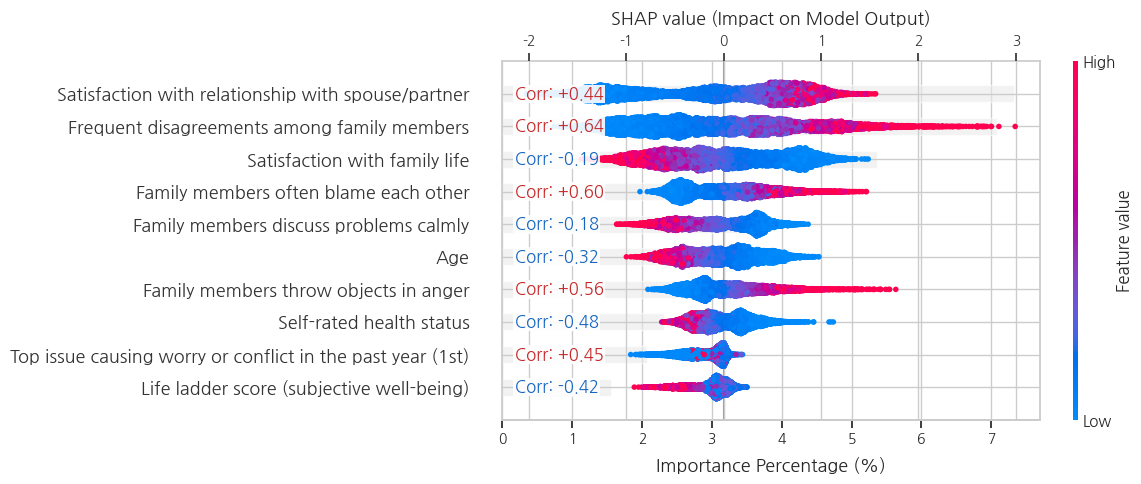

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 473.35it/s]



------------------------------------------------------------
### [Housing type] - Apartment Group Analysis (Test Set) ###
------------------------------------------------------------
* 샘플 수 - Test: 9079명

[Apartment] 1. Calculate Contributions (Test)
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 536.42it/s]



[Apartment] 2. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


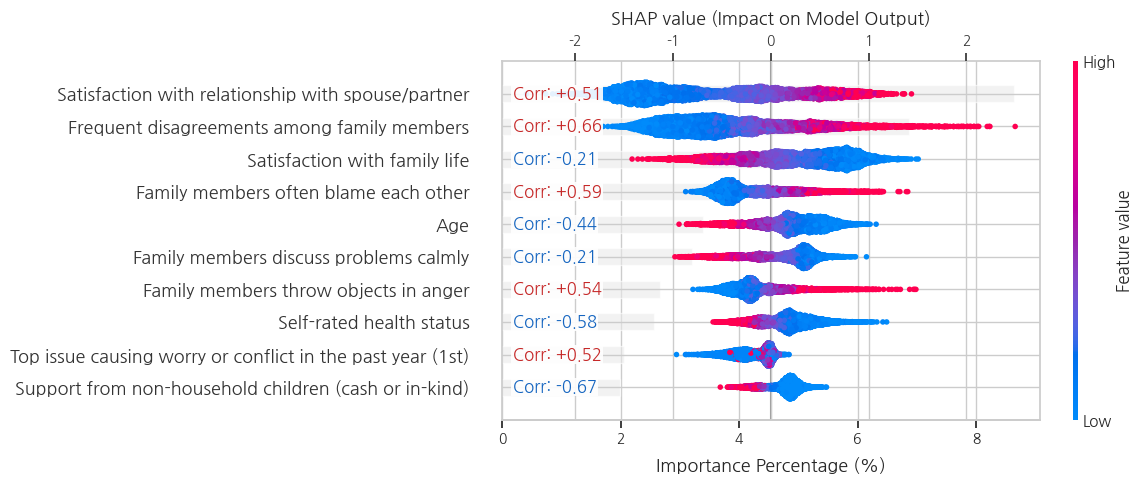

Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|█████████████████████████████████████████████████████| 108/108 [00:00<00:00, 547.80it/s]



### Group Rank & Direction Master Table (Test Set, Split by: Housing type) ###


,Feature,Rank_Total,DirectionPearson_Total,Directional Crach,Rank Reversal,Intensity Disparity
5,Age,6,-0.4240,NaN,NaN,Non-Apartment vs Apartment 격차(0.123)
10,Life ladder score (subjective well-being),11,-0.3331,NaN,NaN,Non-Apartment vs Apartment 격차(0.188)
15,Food expenditure—alcohol & tobacco,16,0.5656,NaN,[4위차] Non-Apartment(15) vs Apartment(19),NaN
17,Belief both men and women should contribute to household income,18,0.5340,NaN,[4위차] Non-Apartment(16) vs Apartment(20),NaN
18,I have little to be proud of,19,0.5754,NaN,[10위차] Apartment(14) vs Non-Apartment(24),NaN
19,Education—public education cost,20,-0.4699,NaN,[8위차] Apartment(15) vs Non-Apartment(23),NaN
20,Region classification (7-region scheme),21,-0.3826,NaN,[3위차] Non-Apartment(21) vs Apartment(24),NaN
21,Overall I am satisfied with myself,22,-0.2001,NaN,[4위차] Apartment(21) vs Non-Apartment(25),NaN
22,Work duration (days),23,-0.0301,Non-Apartment(-) vs Apartment(+),[26위차] Non-Apartment(12) vs Apartment(38),NaN
23,Culture & recreation expenditure,24,0.3474,NaN,[9위차] Non-Apartment(20) vs Apartment(29),NaN



📈 Custom Bump Chart: 하위 집단 간 Feature 중요도 및 방향성 (Test Set)


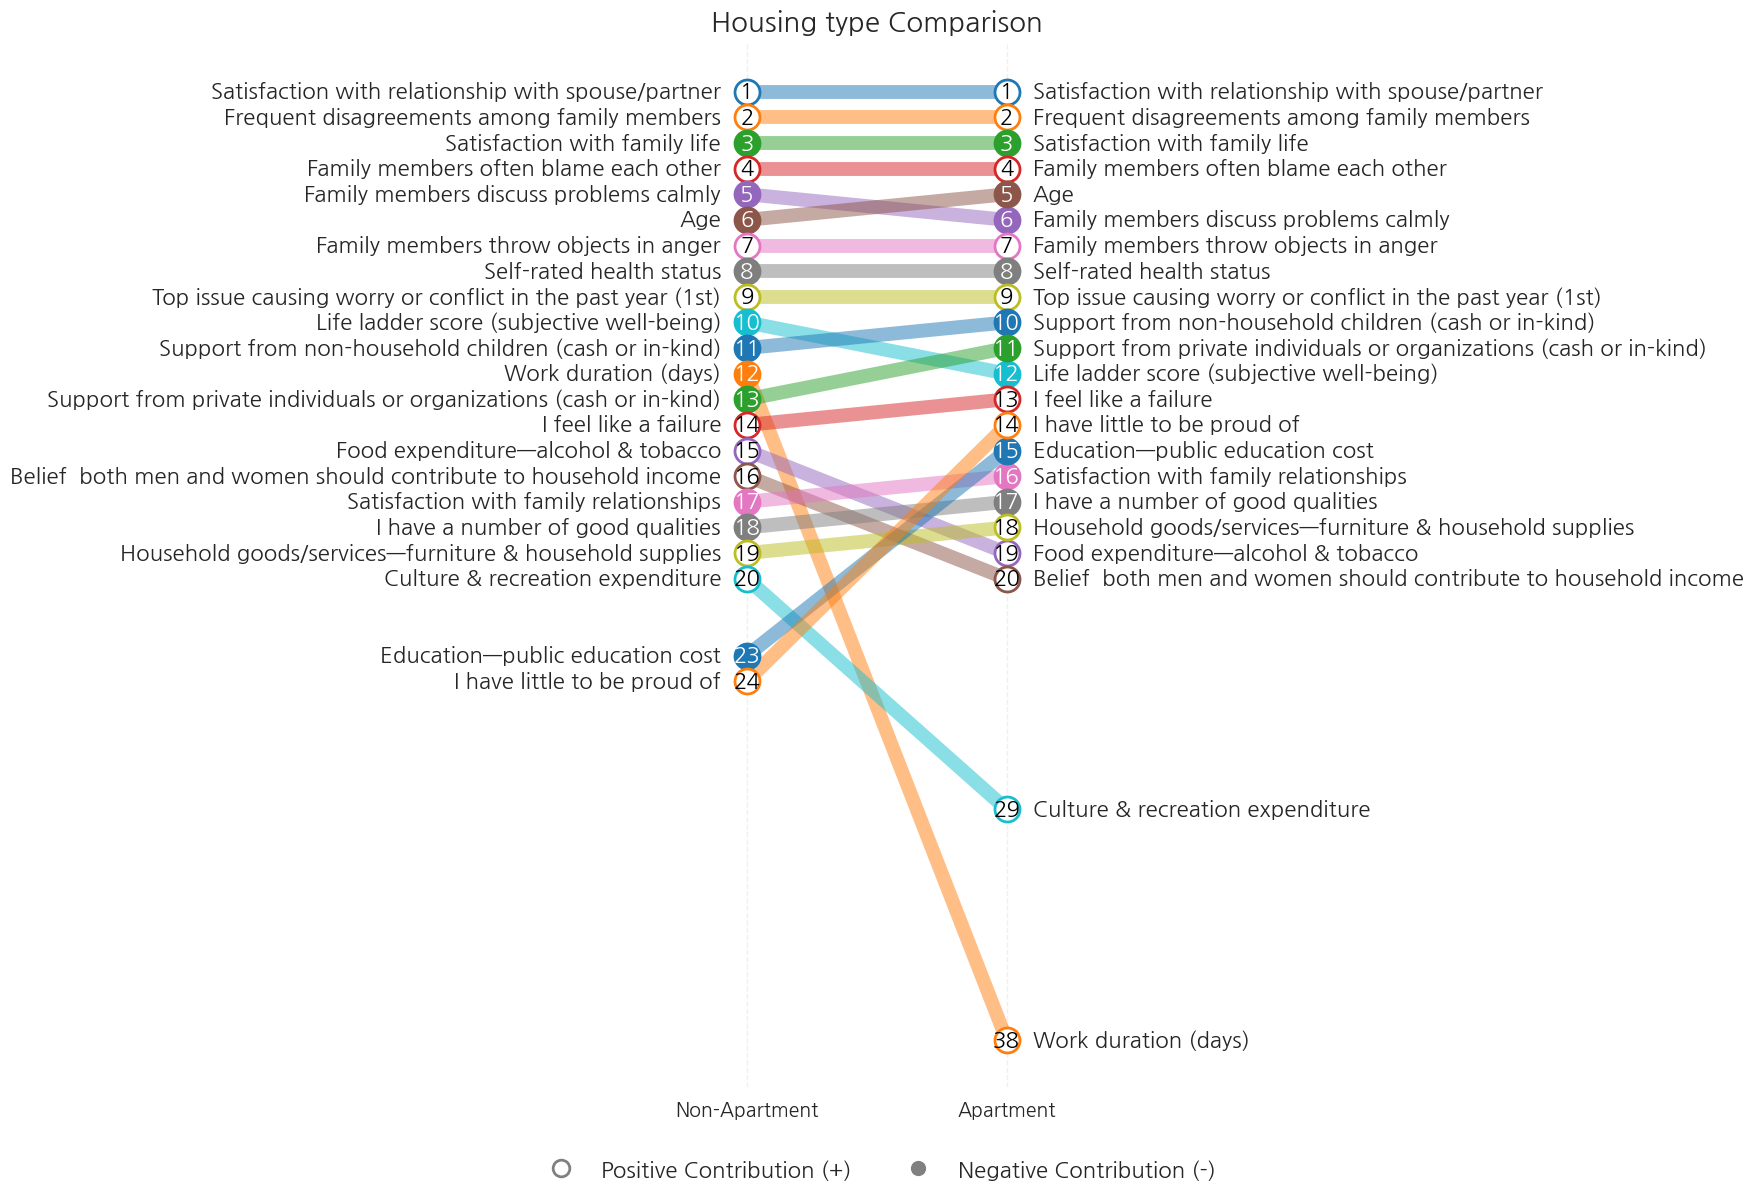


마스터 테이블이 저장되었습니다: /mnt/c/DataScience/Publication/202402_IPVPrediction/Result/FeatureImportance_XGBoost_Test_Housing type.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [42]:
# Housing3
target_group = 'Housing type' # 'Satisfaction with housing environment' 
groups = {
    'Non-Apartment': lambda x: x != 5,
    # 'Middle (Q1-Q3)': lambda x: (x >= df_final[target_group].quantile(0.25)) & (x < df_final[target_group].quantile(0.75)),
    'Apartment': lambda x: x == 5
}
key_features=None
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness_cash = evaluation_class_GroupFairness(
    best_model=BEST_MODEL,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
)

df_comp_train_cash, df_comp_test_cash = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test,
    X_colname=X_colname,
    best_algo=BEST_ALGO,
    max_display=10,
    save_csv=True,
    target_features=key_features
)